# Projeto 03 — Alerta Vermelho: Crise Ambiental Misteriosa
**MBA em Ciência de Dados — UNIFOR** | **Disciplina:** Programação para Ciência de Dados

## Passo 1: Formatação e Análise de Inconsistências no Dados
Nesta etapa inicial, vamos configurar nosso ambiente, carregar os dados fornecidos pela Secretaria de Meio Ambiente e fazer a primeira inspeção das evidências. Nosso objetivo imediato é entender o volume de dados, os tipos de variáveis e mapear inconsistências crônicas, como os valores negativos de NO2 relatados no briefing da operação.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configurações visuais padronizadas para o relatório
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
warnings.filterwarnings('ignore')

In [4]:
# Carregando as evidências
df_ar = pd.read_csv('../data/projeto_03_qualidade_ar.csv')
df_internacoes = pd.read_csv('../data/projeto_03_internacoes_respiratorias.csv')
df_industrias = pd.read_csv('../data/projeto_03_cadastro_industrias.csv')

# Visualizando as primeiras linhas e a estrutura do dataset de Qualidade do Ar
display(df_ar.head())

print("\n--- Informações Estruturais (Qualidade do Ar) ---")
df_ar.info()

print("\n--- Resumo Estatístico (Buscando anomalias como NO2 negativo) ---")
display(df_ar.describe())

,data,hora,estacao,tipo_zona,mp25_ugm3,mp10_ugm3,o3_ugm3,no2_ugm3,so2_ugm3,temperatura_c,umidade_relativa_pct
0,2023-01-01,0,Centro,urbana,25.9,49.4,16.8,22.5,8.7,24.1,73.8
1,2023-01-01,6,Centro,urbana,NaN,30.8,24.1,30.4,14.6,27.6,82.3
2,2023-01-01,12,Centro,urbana,25.7,32.9,45.4,23.7,7.0,26.8,83.9
3,2023-01-01,18,Centro,urbana,27.2,41.5,60.7,28.6,11.9,25.9,81.8
4,2023-01-01,22,Centro,urbana,5.7,36.1,50.9,20.3,7.2,26.8,86.1



--- Informações Estruturais (Qualidade do Ar) ---
<class 'pandas.DataFrame'>
RangeIndex: 29200 entries, 0 to 29199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   data                  29200 non-null  str    
 1   hora                  29200 non-null  int64  
 2   estacao               29200 non-null  str    
 3   tipo_zona             29200 non-null  str    
 4   mp25_ugm3             28055 non-null  float64
 5   mp10_ugm3             28044 non-null  float64
 6   o3_ugm3               28054 non-null  float64
 7   no2_ugm3              29200 non-null  float64
 8   so2_ugm3              29200 non-null  float64
 9   temperatura_c         29200 non-null  float64
 10  umidade_relativa_pct  29200 non-null  float64
dtypes: float64(7), int64(1), str(3)
memory usage: 2.5 MB

--- Resumo Estatístico (Buscando anomalias como NO2 negativo) ---


,hora,mp25_ugm3,mp10_ugm3,o3_ugm3,no2_ugm3,so2_ugm3,temperatura_c,umidade_relativa_pct
count,29200.000000,28055.000000,28044.000000,28054.000000,29200.000000,29200.000000,29200.000000,29200.000000
mean,11.600000,27.839761,48.202753,38.941616,29.119610,12.993240,28.296134,69.418144
std,7.939909,20.019597,30.845629,16.391143,15.151941,11.422089,3.077217,15.966003
min,0.000000,1.000000,2.000000,0.000000,-77.200000,0.000000,17.200000,20.000000
25%,6.000000,14.200000,25.700000,27.700000,19.400000,7.000000,26.100000,57.300000
50%,12.000000,21.600000,38.300000,38.700000,27.500000,10.700000,28.200000,68.800000
75%,18.000000,36.200000,64.600000,50.100000,36.400000,15.400000,30.400000,82.900000
max,22.000000,181.700000,250.800000,103.000000,126.500000,95.600000,41.100000,100.000000


## Passo 2: Tratamento e Limpeza

A inspeção inicial revelou ruídos nos equipamentos de medição. Identificamos registros fisicamente impossíveis (concentrações negativas de Dióxido de Nitrogênio) e lacunas nas leituras de material particulado e ozônio, indicando possíveis falhas temporais nos sensores das estações.

Para garantir a integridade da nossa investigação sem perder dados valiosos, nossa estratégia de limpeza será:
1. **Isolar o erro de medição:** Substituir valores negativos de NO2 por nulos (`NaN`).
2. **Reconstruir a linha do tempo:** Converter todas as colunas de data para o formato `datetime` nativo do Pandas.
3. **Preencher as lacunas (Imputação):** Como a poluição do ar é um processo contínuo no tempo, utilizaremos a **interpolação linear** agrupada por estação. Isso estima os valores ausentes com base nas medições imediatamente anteriores e posteriores, oferecendo a aproximação mais realista da realidade.

In [5]:
# 1. Tratamento da anomalia do NO2
qtd_erros_no2 = (df_ar['no2_ugm3'] < 0).sum()
print(f"Encontrados e isolados {qtd_erros_no2} registros com erro de NO2 negativo.")

# Substituindo os valores negativos por NaN (Nulo)
df_ar.loc[df_ar['no2_ugm3'] < 0, 'no2_ugm3'] = np.nan

# 2. Conversão de Tipos (Datas)
df_ar['data'] = pd.to_datetime(df_ar['data'])
df_internacoes['data_internacao'] = pd.to_datetime(df_internacoes['data_internacao'])

# O errors='coerce' transforma datas inválidas no cadastro de indústrias em NaT (Not a Time)
if 'data_ultima_fiscalizacao' in df_industrias.columns:
    df_industrias['data_ultima_fiscalizacao'] = pd.to_datetime(df_industrias['data_ultima_fiscalizacao'], errors='coerce')

# 3. Ordenação temporal e Interpolação
# Precisamos garantir que os dados estão em ordem cronológica antes de interpolar
df_ar = df_ar.sort_values(by=['estacao', 'data', 'hora']).reset_index(drop=True)

# Selecionando apenas as colunas de poluentes para a imputação
colunas_poluentes = ['mp25_ugm3', 'mp10_ugm3', 'o3_ugm3', 'no2_ugm3']

# Aplicando a interpolação linear agrupada por estação
df_ar[colunas_poluentes] = df_ar.groupby('estacao')[colunas_poluentes].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both')
)

# Verificação pós-limpeza
print("\n--- Auditoria de Nulos após Tratamento ---")
print(df_ar.isna().sum())

Encontrados e isolados 19 registros com erro de NO2 negativo.

--- Auditoria de Nulos após Tratamento ---
data                    0
hora                    0
estacao                 0
tipo_zona               0
mp25_ugm3               0
mp10_ugm3               0
o3_ugm3                 0
no2_ugm3                0
so2_ugm3                0
temperatura_c           0
umidade_relativa_pct    0
dtype: int64


## Passo 3: Dinâmica de Emissões e a Prova do Crime

Com as evidências na mesa, a estratégia agora é cruzar o tipo de poluente com o relógio da cidade. Como sabemos que poeira (MP) e gases industriais (SO2/NO2) têm comportamentos diferentes, precisamos estabelecer uma linha de base e isolar as anomalias.

**O pipeline desta etapa:**
1. **Baseline (Média 24h):** Entender qual é o nível "normal" de poluição na cidade.
2. **Split Temporal (Diurno vs. Noturno):** Separar o horário comercial da madrugada para identificar picos de emissão fora do padrão.
3. **Cálculo de Desvio Relativo:** Medir, em porcentagem, o quanto cada estação está estourando o limite em relação à média geral.
4. **Dossiê Industrial:** Puxar a ficha completa das empresas localizadas no epicentro da poluição (Jurema).

 PANORAMA GERAL: MÉDIA DE 24 HORAS (Todos os Poluentes)
Legenda: (*) Bairro possui indústrias na nossa base de dados.



,mp25_ugm3,mp10_ugm3,no2_ugm3,so2_ugm3,Total_Poluentes
estacao,,,,,
Jurema *,58.97,96.27,48.71,31.65,235.59
Porto *,39.02,68.69,31.69,16.00,155.40
Distrito Industrial *,39.04,68.84,31.27,15.95,155.09
Centro,24.50,43.49,24.17,8.06,100.22
Aldeota,16.73,29.47,24.59,7.99,78.78
Maraponga *,16.62,29.61,24.37,8.13,78.73
Messejana *,16.74,29.41,24.38,8.08,78.60
Parque do Cocó,11.14,19.66,24.07,8.10,62.98


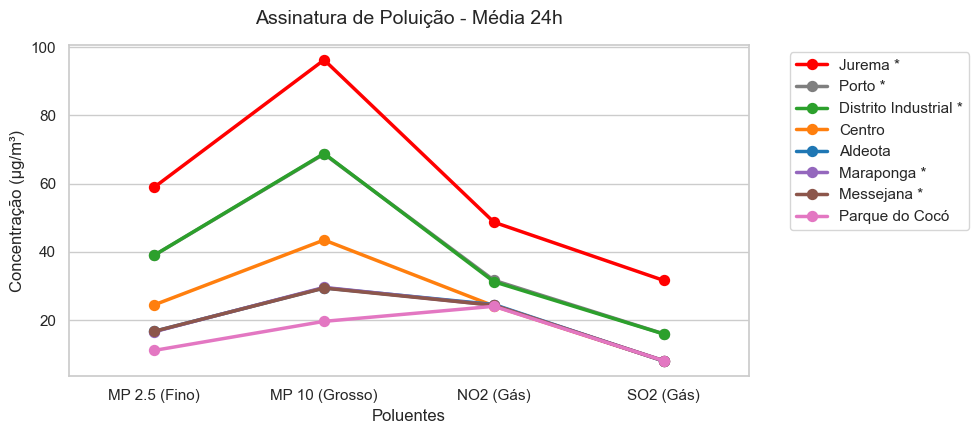

--- Desvio da Média Geral (24h) (Relativo) ---
*(Valores em %, indicam o quanto a estação está acima/abaixo da média da cidade)*


,mp25_ugm3,mp10_ugm3,no2_ugm3,so2_ugm3
estacao,,,,
Jurema *,+111.76%,+99.81%,+67.07%,+143.56%
Porto *,+40.13%,+42.57%,+8.70%,+23.14%
Distrito Industrial *,+40.21%,+42.88%,+7.24%,+22.72%
Centro,-12.03%,-9.73%,-17.10%,-37.99%
Aldeota,-39.91%,-38.83%,-15.65%,-38.51%
Maraponga *,-40.32%,-38.54%,-16.43%,-37.39%
Messejana *,-39.87%,-38.97%,-16.38%,-37.85%
Parque do Cocó,-59.98%,-59.18%,-17.44%,-37.68%



 INVESTIGAÇÃO DE POLUENTES: DIURNO (6h, 12h, 18h)
--- Material Particulado (Poeira/Fuligem) - Média Diurna ---


,mp25_ugm3,mp10_ugm3
estacao,,
Jurema *,43.82,76.06
Porto *,42.97,75.52
Distrito Industrial *,42.71,75.38
Centro,26.99,47.61
Aldeota,18.42,32.44
Messejana *,18.34,32.37
Maraponga *,18.29,32.43
Parque do Cocó,12.24,21.58


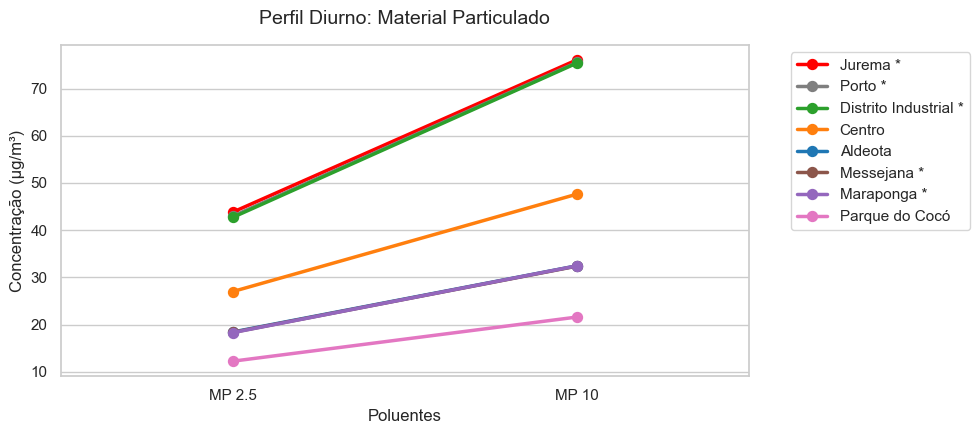

--- Desvio da Média Diurna (Particulados) (Relativo) ---
*(Valores em %, indicam o quanto a estação está acima/abaixo da média da cidade)*


,mp25_ugm3,mp10_ugm3
estacao,,
Jurema *,+56.66%,+54.68%
Porto *,+53.60%,+53.58%
Distrito Industrial *,+52.69%,+53.28%
Centro,-3.50%,-3.17%
Aldeota,-34.14%,-34.04%
Messejana *,-34.44%,-34.18%
Maraponga *,-34.62%,-34.05%
Parque do Cocó,-56.26%,-56.11%



--- Gases Tóxicos Industriais (Combustão) - Média Diurna ---


,no2_ugm3,so2_ugm3
estacao,,
Distrito Industrial *,34.47,16.07
Porto *,34.85,15.97
Jurema *,34.48,15.80
Messejana *,26.81,8.11
Maraponga *,26.74,8.07
Parque do Cocó,26.63,8.05
Centro,26.72,7.91
Aldeota,27.22,7.89


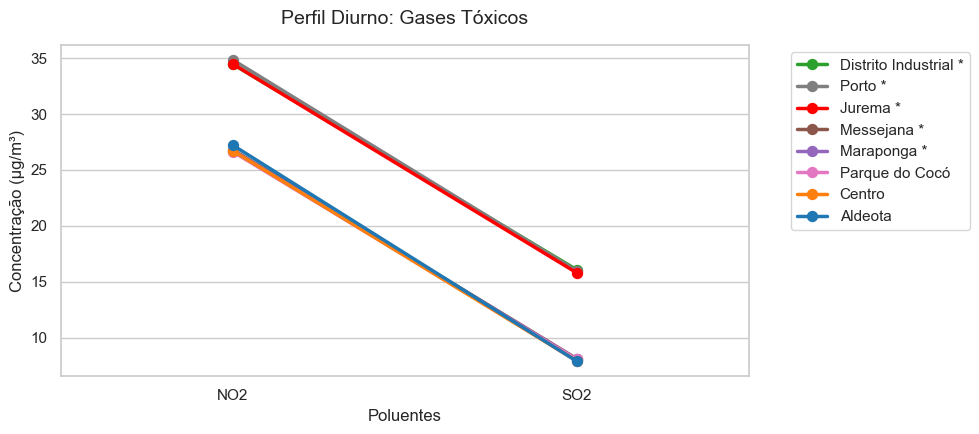

--- Desvio da Média Diurna (Gases Tóxicos) (Relativo) ---
*(Valores em %, indicam o quanto a estação está acima/abaixo da média da cidade)*


,no2_ugm3,so2_ugm3
estacao,,
Distrito Industrial *,+15.89%,+46.33%
Porto *,+17.19%,+45.39%
Jurema *,+15.94%,+43.83%
Messejana *,-9.86%,-26.15%
Maraponga *,-10.09%,-26.54%
Parque do Cocó,-10.44%,-26.75%
Centro,-10.16%,-27.98%
Aldeota,-8.48%,-28.13%



 INVESTIGAÇÃO DE POLUENTES: NOTURNO (22h, 0h)
--- Material Particulado (Poeira/Fuligem) - Média Noturna ---


,mp25_ugm3,mp10_ugm3
estacao,,
Jurema *,81.68,126.58
Distrito Industrial *,33.54,59.03
Porto *,33.10,58.44
Centro,20.75,37.31
Messejana *,14.35,24.96
Aldeota,14.19,25.02
Maraponga *,14.11,25.39
Parque do Cocó,9.50,16.79


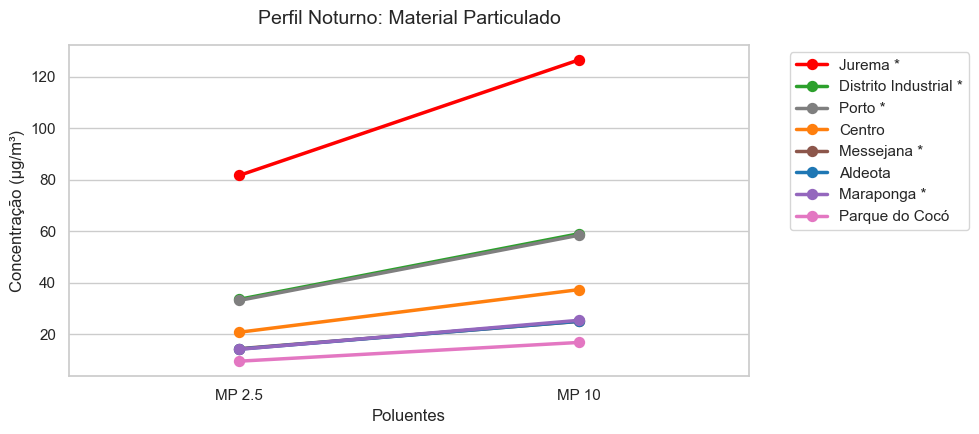

--- Desvio da Média Noturna (Particulados) (Relativo) ---
*(Valores em %, indicam o quanto a estação está acima/abaixo da média da cidade)*


,mp25_ugm3,mp10_ugm3
estacao,,
Jurema *,+195.37%,+171.11%
Distrito Industrial *,+21.27%,+26.43%
Porto *,+19.69%,+25.16%
Centro,-24.97%,-20.08%
Messejana *,-48.11%,-46.54%
Aldeota,-48.67%,-46.41%
Maraponga *,-48.96%,-45.62%
Parque do Cocó,-65.63%,-64.05%



--- Gases Tóxicos Industriais (Combustão) - Média Noturna ---


,no2_ugm3,so2_ugm3
estacao,,
Jurema *,70.05,55.41
Porto *,26.95,16.04
Distrito Industrial *,26.47,15.75
Centro,20.34,8.27
Maraponga *,20.81,8.23
Parque do Cocó,20.23,8.17
Aldeota,20.65,8.13
Messejana *,20.73,8.02


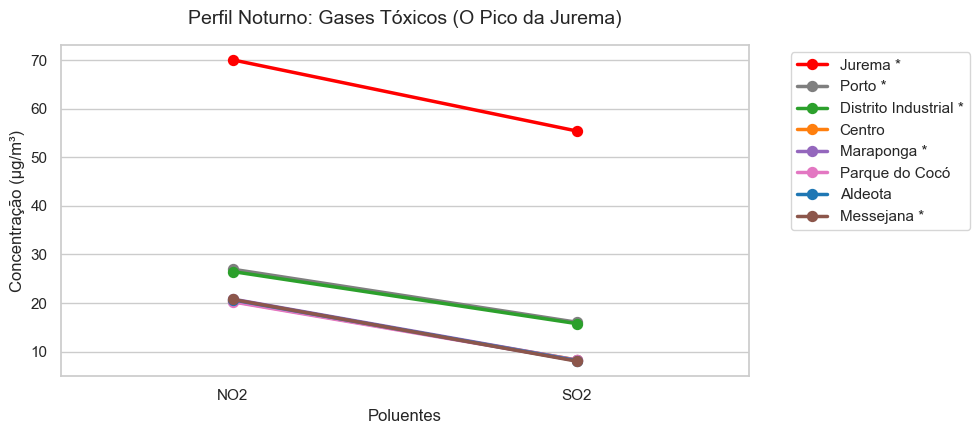

--- Desvio da Média Noturna (Gases Tóxicos) (Relativo) ---
*(Valores em %, indicam o quanto a estação está acima/abaixo da média da cidade)*


,no2_ugm3,so2_ugm3
estacao,,
Jurema *,+147.72%,+246.21%
Porto *,-4.70%,+0.24%
Distrito Industrial *,-6.41%,-1.58%
Centro,-28.07%,-48.30%
Maraponga *,-26.43%,-48.57%
Parque do Cocó,-28.47%,-48.93%
Aldeota,-26.97%,-49.19%
Messejana *,-26.68%,-49.89%



 AUDITORIA INDUSTRIAL: O FOCO NA JUREMA

--- Ficha Completa das Indústrias Localizadas na Jurema ---


,industria_id,nome,bairro,tipo_atividade,porte,licenca_ambiental,data_ultima_fiscalizacao,horario_operacao_declarado,emissoes_declaradas_ton_ano
0,IND-001,QuimNorte Ltda,Jurema,Química Industrial,Grande,Vencida,2021-08-15,08:00-18:00,12.5
3,IND-004,PlastCE Indústria,Jurema,Plásticos,Médio,Vigente,2023-11-05,08:00-18:00,3.2


In [6]:
# ==============================================================================
# 1. SETUP VISUAL E IDENTIDADE DO RELATÓRIO
# ==============================================================================

# Identificando dinamicamente os bairros que possuem cadastro industrial
bairros_com_industria = df_industrias['bairro'].unique()

# Função auxiliar para marcar as estações com asterisco
def marcar_estacao(nome_estacao):
    return f"{nome_estacao} *" if nome_estacao in bairros_com_industria else nome_estacao

# Criando a paleta de cores FIXA já com os asteriscos nos nomes
estacoes_originais = df_ar['estacao'].unique()
paleta = sns.color_palette("tab10", len(estacoes_originais))
cores_estacoes = {marcar_estacao(est): cor for est, cor in zip(estacoes_originais, paleta)}

# Forçando o destaque vermelho para a Jurema (A suspeita principal)
cores_estacoes[marcar_estacao('Jurema')] = 'red'

# Função para padronizar e plotar os gráficos
def plotar_perfil(df_tabela, titulo, labels_x):
    if 'Total_Poluentes' in df_tabela.columns:
        df_plot = df_tabela.drop(columns=['Total_Poluentes'])
    else:
        df_plot = df_tabela.copy()
        
    df_melt = df_plot.reset_index().melt(id_vars='estacao', var_name='Poluente', value_name='Concentração (µg/m³)')
    
    plt.figure(figsize=(10, 4.5))
    sns.pointplot(
        data=df_melt, x='Poluente', y='Concentração (µg/m³)', 
        hue='estacao', palette=cores_estacoes, markers='o', linewidth=2.5
    )
    plt.title(titulo, fontsize=14, pad=15)
    plt.xlabel('Poluentes', fontsize=12)
    plt.ylabel('Concentração (µg/m³)', fontsize=12)
    plt.xticks(ticks=range(len(labels_x)), labels=labels_x)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Função para calcular e exibir a tabela de desvios percentuais em relação à média
def mostrar_desvios(df_tabela, titulo_desvio):
    if 'Total_Poluentes' in df_tabela.columns:
        df_calc = df_tabela.drop(columns=['Total_Poluentes'])
    else:
        df_calc = df_tabela.copy()
        
    # Calcula a média geral de cada coluna (a média da cidade inteira)
    media_cidade = df_calc.mean()
    
    # Calcula o desvio relativo (percentual): ((Valor - Média) / Média) * 100
    df_desvio_pct = ((df_calc - media_cidade) / media_cidade) * 100
    
    print(f"--- {titulo_desvio} (Relativo) ---")
    print("*(Valores em %, indicam o quanto a estação está acima/abaixo da média da cidade)*")
    
    # Formatando para exibir com o sinal e o símbolo de %
    df_formatado = df_desvio_pct.apply(lambda col: col.map("{:+.2f}%".format))
    display(df_formatado)

# ==============================================================================
# 2. PANORAMA GERAL (24 HORAS)
# ==============================================================================
print("="*60)
print(" PANORAMA GERAL: MÉDIA DE 24 HORAS (Todos os Poluentes)")
print("="*60)
print("Legenda: (*) Bairro possui indústrias na nossa base de dados.\n")

panorama_geral = df_ar.groupby('estacao')[['mp25_ugm3', 'mp10_ugm3', 'no2_ugm3', 'so2_ugm3']].mean()
panorama_geral['Total_Poluentes'] = panorama_geral.sum(axis=1)
panorama_geral = panorama_geral.sort_values(by='Total_Poluentes', ascending=False)
panorama_geral.index = panorama_geral.index.map(marcar_estacao)

display(panorama_geral.round(2))
plotar_perfil(
    panorama_geral, 
    'Assinatura de Poluição - Média 24h', 
    ['MP 2.5 (Fino)', 'MP 10 (Grosso)', 'NO2 (Gás)', 'SO2 (Gás)']
)
mostrar_desvios(panorama_geral, 'Desvio da Média Geral (24h)')

# Separando os dataframes por período para a análise detalhada
diurno_df = df_ar[df_ar['hora'].isin([6, 12, 18])]
noturno_df = df_ar[df_ar['hora'].isin([22, 0])]

# ==============================================================================
# 3. INVESTIGAÇÃO DIURNA (6h, 12h, 18h)
# ==============================================================================
print("\n" + "="*60)
print(" INVESTIGAÇÃO DE POLUENTES: DIURNO (6h, 12h, 18h)")
print("="*60)

# --- Material Particulado (Diurno) ---
poeira_diurna = diurno_df.groupby('estacao')[['mp25_ugm3', 'mp10_ugm3']].mean().sort_values(by='mp25_ugm3', ascending=False)
poeira_diurna.index = poeira_diurna.index.map(marcar_estacao)
print("--- Material Particulado (Poeira/Fuligem) - Média Diurna ---")
display(poeira_diurna.round(2))
plotar_perfil(poeira_diurna, 'Perfil Diurno: Material Particulado', ['MP 2.5', 'MP 10'])
mostrar_desvios(poeira_diurna, 'Desvio da Média Diurna (Particulados)')

# --- Gases Industriais (Diurno) ---
gases_diurnos = diurno_df.groupby('estacao')[['no2_ugm3', 'so2_ugm3']].mean().sort_values(by='so2_ugm3', ascending=False)
gases_diurnos.index = gases_diurnos.index.map(marcar_estacao)
print("\n--- Gases Tóxicos Industriais (Combustão) - Média Diurna ---")
display(gases_diurnos.round(2))
plotar_perfil(gases_diurnos, 'Perfil Diurno: Gases Tóxicos', ['NO2', 'SO2'])
mostrar_desvios(gases_diurnos, 'Desvio da Média Diurna (Gases Tóxicos)')

# ==============================================================================
# 4. INVESTIGAÇÃO NOTURNA (22h, 0h) - A HORA DO CRIME
# ==============================================================================
print("\n" + "="*60)
print(" INVESTIGAÇÃO DE POLUENTES: NOTURNO (22h, 0h)")
print("="*60)

# --- Material Particulado (Noturno) ---
poeira_noturna = noturno_df.groupby('estacao')[['mp25_ugm3', 'mp10_ugm3']].mean().sort_values(by='mp25_ugm3', ascending=False)
poeira_noturna.index = poeira_noturna.index.map(marcar_estacao)
print("--- Material Particulado (Poeira/Fuligem) - Média Noturna ---")
display(poeira_noturna.round(2))
plotar_perfil(poeira_noturna, 'Perfil Noturno: Material Particulado', ['MP 2.5', 'MP 10'])
mostrar_desvios(poeira_noturna, 'Desvio da Média Noturna (Particulados)')

# --- Gases Industriais (Noturno) ---
gases_noturnos = noturno_df.groupby('estacao')[['no2_ugm3', 'so2_ugm3']].mean().sort_values(by='so2_ugm3', ascending=False)
gases_noturnos.index = gases_noturnos.index.map(marcar_estacao)
print("\n--- Gases Tóxicos Industriais (Combustão) - Média Noturna ---")
display(gases_noturnos.round(2))
plotar_perfil(gases_noturnos, 'Perfil Noturno: Gases Tóxicos (O Pico da Jurema)', ['NO2', 'SO2'])
mostrar_desvios(gases_noturnos, 'Desvio da Média Noturna (Gases Tóxicos)')

# ==============================================================================
# 5. AUDITORIA INDUSTRIAL: O FOCO NA JUREMA
# ==============================================================================
print("\n" + "="*60)
print(" AUDITORIA INDUSTRIAL: O FOCO NA JUREMA")
print("="*60)

industrias_jurema = df_industrias[df_industrias['bairro'] == 'Jurema']
print("\n--- Ficha Completa das Indústrias Localizadas na Jurema ---")
display(industrias_jurema)

## Passo 4: Auditoria de Zoneamento (O Fator "Tipo de Zona")

Antes de partirmos para os dados de saúde pública, precisamos validar uma variável categórica crucial do nosso dataset ambiental: o `tipo_zona`. Nosso objetivo aqui é entender a granularidade dessas medições. 

Será que a estação Jurema mistura dados de áreas residenciais com polos industriais? Vamos levantar o número de registros e mapear os tipos de zoneamento (tanto da cidade quanto especificamente da nossa principal suspeita) para garantir que não há viés de localização mascarando nossos resultados.

In [7]:
# ==============================================================================
# 1. AUDITORIA DE ZONEAMENTO AMBIENTAL
# ==============================================================================

# Isolando apenas os dados da estação Jurema
# Obs: Como não alteramos o nome na base original df_ar, buscamos por 'Jurema'
df_jurema = df_ar[df_ar['estacao'] == 'Jurema']

# Levantamento das métricas solicitadas
total_registros_jurema = len(df_jurema)

tipos_zona_cidade = df_ar['tipo_zona'].unique()
qtd_zonas_cidade = df_ar['tipo_zona'].nunique()

tipos_zona_jurema = df_jurema['tipo_zona'].unique()
qtd_zonas_jurema = df_jurema['tipo_zona'].nunique()

# Exibindo o relatório
print("="*60)
print(" RELATÓRIO DE ZONEAMENTO: CIDADE VS. JUREMA")
print("="*60)

print(f"-> Total de registros (linhas) da estação Jurema: {total_registros_jurema}\n")

print(f"-> Tipos de zona existentes em toda a base da cidade ({qtd_zonas_cidade} no total):")
for zona in tipos_zona_cidade:
    print(f"   - {zona.capitalize()}")

print(f"\n-> Tipos de zona encontrados ESPECIFICAMENTE na estação Jurema ({qtd_zonas_jurema} no total):")
for zona in tipos_zona_jurema:
    print(f"   - {zona.capitalize()}")
    
# Verificando se a Jurema tem alguma inconsistência de zoneamento (mais de um tipo)
if qtd_zonas_jurema > 1:
    print("\n[ALERTA] A estação Jurema possui sensores em zonas diferentes. Precisaremos separar isso na análise!")
else:
    print("\n[OK] A estação Jurema é padronizada. Todos os sensores estão no mesmo tipo de zona.")

 RELATÓRIO DE ZONEAMENTO: CIDADE VS. JUREMA
-> Total de registros (linhas) da estação Jurema: 3650

-> Tipos de zona existentes em toda a base da cidade (4 no total):
   - Residencial
   - Urbana
   - Industrial
   - Parque

-> Tipos de zona encontrados ESPECIFICAMENTE na estação Jurema (1 no total):
   - Industrial

[OK] A estação Jurema é padronizada. Todos os sensores estão no mesmo tipo de zona.


## Passo 5: Elementar, meu caro Watson! (Mapeamento de Zoneamento)

A descoberta de que a estação Jurema é 100% composta por sensores de zona industrial levanta uma nova e intrigante hipótese: será que esse é o padrão arquitetural do nosso banco de dados, ou existem estações mistas que poderiam estar sujando nossas médias?

Para garantir a integridade da nossa "Cena do Crime", vamos fazer uma varredura completa. Precisamos auditar cada uma das 8 estações para contabilizar o volume de registros, a quantidade de zonas diferentes que cada uma abrange e, finalmente, listar a distribuição exata de medições por tipo de zona.

In [8]:
# ==============================================================================
# 5. AUDITORIA GLOBAL DE ZONEAMENTO POR ESTAÇÃO
# ==============================================================================

print("="*60)
print(" VISÃO GERAL: REGISTROS E TIPOS DE ZONA POR ESTAÇÃO")
print("="*60)

# 1. Tabela resumo: Total de registros, quantidade de zonas únicas e quais são elas
# Correção: Aplicando list comprehension para garantir a formatação correta do texto
resumo_zonas = df_ar.groupby('estacao').agg(
    Total_Registros=('estacao', 'count'),
    Qtd_Tipos_Zona=('tipo_zona', 'nunique'),
    Zonas_Listadas=('tipo_zona', lambda x: ', '.join([str(z).capitalize() for z in x.unique()]))
).sort_values(by='Total_Registros', ascending=False)

print("--- Resumo de Granularidade ---")
display(resumo_zonas)


print("\n" + "="*60)
print(" DETALHAMENTO: VOLUME DE MEDIÇÕES POR TIPO DE ZONA")
print("="*60)

# 2. Tabela dinâmica (Pivot Table): Mostra exatamente quantos registros existem de cada tipo
contagem_zonas = df_ar.groupby(['estacao', 'tipo_zona']).size().reset_index(name='Registros')
contagem_zonas['tipo_zona'] = contagem_zonas['tipo_zona'].str.capitalize()

# Criando a Pivot Table e preenchendo o que não existe com 0
pivot_zonas = contagem_zonas.pivot(index='estacao', columns='tipo_zona', values='Registros').fillna(0).astype(int)

# Reordenando as colunas para ficar visualmente organizado
colunas_ordem = [col for col in ['Urbana', 'Residencial', 'Industrial', 'Parque'] if col in pivot_zonas.columns]
pivot_zonas = pivot_zonas[colunas_ordem]

print("--- Distribuição Exata de Registros ---")
display(pivot_zonas)

 VISÃO GERAL: REGISTROS E TIPOS DE ZONA POR ESTAÇÃO
--- Resumo de Granularidade ---


,Total_Registros,Qtd_Tipos_Zona,Zonas_Listadas
estacao,,,
Aldeota,3650,1,Residencial
Centro,3650,1,Urbana
Distrito Industrial,3650,1,Industrial
Jurema,3650,1,Industrial
Maraponga,3650,1,Residencial
Messejana,3650,1,Residencial
Parque do Cocó,3650,1,Parque
Porto,3650,1,Industrial



 DETALHAMENTO: VOLUME DE MEDIÇÕES POR TIPO DE ZONA
--- Distribuição Exata de Registros ---


tipo_zona,Urbana,Residencial,Industrial,Parque
estacao,,,,
Aldeota,0,3650,0,0
Centro,3650,0,0,0
Distrito Industrial,0,0,3650,0
Jurema,0,0,3650,0
Maraponga,0,3650,0,0
Messejana,0,3650,0,0
Parque do Cocó,0,0,0,3650
Porto,0,0,3650,0


### Conclusão do Zoneamento: O Viés de Amostragem Escancarado

A matriz de distribuição revela uma arquitetura de dados cirurgicamente controlada: cada uma das 8 estações possui exatos 3.650 registros concentrados em um **único tipo de zona**. A estação Jurema, por exemplo, foi medida 100% sob a ótica "Industrial".

Do ponto de vista analítico, isso levanta um forte indício de **viés de amostragem** espacial na instalação dos sensores. Caracterizar a qualidade do ar de um bairro inteiro baseando-se em um único microambiente distorce a realidade heterogênea do local. 

A prova definitiva dessa metodologia "safada" (ou no mínimo, enviesada) vem quando cruzamos essa descoberta de zoneamento com o nosso ranking geral de poluição. As três estações com a pior qualidade de ar da cidade são exatamente as três únicas instaladas exclusivamente em polos industriais. Isso nos mostra que os dados não estão apenas contando uma história sobre o ar, mas também sobre onde escolheram colocar a lupa.

In [9]:
# ==============================================================================
# O VEREDITO DO VIÉS: RANKING DE POLUIÇÃO VS. TIPO DE ZONA
# ==============================================================================

# Calculando o Total de Poluentes por estação (média de 24h)
ranking_poluicao = df_ar.groupby('estacao')[['mp25_ugm3', 'mp10_ugm3', 'no2_ugm3', 'so2_ugm3']].mean()
ranking_poluicao['Carga_Poluidora_Total'] = ranking_poluicao.sum(axis=1)

# Pegando o tipo de zona único de cada estação (já provamos que só tem 1 por estação)
zonas_estacoes = df_ar.groupby('estacao')['tipo_zona'].first()

# Juntando as informações em uma única tabela
veredito_vies = ranking_poluicao[['Carga_Poluidora_Total']].join(zonas_estacoes)

# Ordenando do pior ar para o melhor
veredito_vies = veredito_vies.sort_values(by='Carga_Poluidora_Total', ascending=False)
veredito_vies['tipo_zona'] = veredito_vies['tipo_zona'].str.capitalize()

print("="*60)
print(" RANKING DA SUJEIRA: A INFLUÊNCIA DO ZONEAMENTO")
print("="*60)
display(veredito_vies.round(2))

 RANKING DA SUJEIRA: A INFLUÊNCIA DO ZONEAMENTO


,Carga_Poluidora_Total,tipo_zona
estacao,,
Jurema,235.59,Industrial
Porto,155.40,Industrial
Distrito Industrial,155.09,Industrial
Centro,100.22,Urbana
Aldeota,78.78,Residencial
Maraponga,78.73,Residencial
Messejana,78.60,Residencial
Parque do Cocó,62.98,Parque


**Observação importante:** Toda essa nossa crítica assume o cenário de uma cidade real com diversidade de zoneamento. Mas, como estamos lidando com uma abstração fictícia (um ambiente de laboratório desenhado para o projeto), uma outra interpretação totalmente válida seria: *toda a área de cobertura daquela estação é, de fato, estritamente daquele tipo de zona!* Fica a observação. :)

## Passo 6: O Raio-X da Saúde Pública (Conciliação de Bases)

Chegou a hora de abrirmos os prontuários! Deixamos a investigação industrial um pouco de lado para focar nas vítimas: as internações respiratórias.

Antes de sair cruzando asma com poluição, nossa primeira missão é fazer a conciliação espacial dos dados. Precisamos saber o volume de pacientes com o qual estamos lidando e, o mais importante, verificar se os bairros de onde essas pessoas vêm batem perfeitamente com as estações de ar que já auditamos. Trabalhar com "bairros fantasmas" em qualquer uma das pontas distorceria totalmente a correlação.

In [10]:
# ==============================================================================
# 6. CONCILIAÇÃO DAS BASES: SAÚDE PÚBLICA VS. QUALIDADE DO AR
# ==============================================================================

# 1. Volume de Dados
total_internacoes = len(df_internacoes)
total_ar = len(df_ar)

print("="*60)
print(" VOLUME DE REGISTROS NOS DATASETS")
print("="*60)
print(f"-> Total de medições de Ar: {total_ar} registros.")
print(f"-> Total de internações hospitalares: {total_internacoes} registros.\n")

# 2. Extraindo nomes (Limpando o ' *' que adicionamos no df_ar lá no Passo 3 para comparar limpo)
estacoes_limpas = set([str(x).replace(' *', '') for x in df_ar['estacao'].unique()])
bairros_internacoes = set(df_internacoes['bairro_residencia'].unique())

# 3. Colocando Lado a Lado visualmente com Pandas
# Nivelamos o tamanho caso uma base tenha mais locais que a outra
max_len = max(len(bairros_internacoes), len(estacoes_limpas))
lista_bairros = sorted(list(bairros_internacoes)) + ['-'] * (max_len - len(bairros_internacoes))
lista_estacoes = sorted(list(estacoes_limpas)) + ['-'] * (max_len - len(estacoes_limpas))

df_match = pd.DataFrame({
    'Bairros Hospitalares (Saúde)': lista_bairros,
    'Estações de Monitoramento (Ar)': lista_estacoes
})

print("="*60)
print(" MAPEAMENTO GEOGRÁFICO: OS LOCAIS BATEM?")
print("="*60)
display(df_match)

# 4. A Prova dos 9: Verificação Matemática do Match
if bairros_internacoes == estacoes_limpas:
    print("\n[MATCH PERFEITO!] Todos os bairros com internações possuem uma estação de monitoramento de ar correspondente.")
else:
    sobrando_saude = bairros_internacoes - estacoes_limpas
    sobrando_ar = estacoes_limpas - bairros_internacoes
    
    print("\n[ALERTA DE DESVIO GEOGRÁFICO]")
    if sobrando_saude: 
        print(f"- Bairros com doentes, mas SEM estação de ar: {sobrando_saude}")
    if sobrando_ar: 
        print(f"- Estações de ar rodando, mas SEM pacientes registrados: {sobrando_ar}")

 VOLUME DE REGISTROS NOS DATASETS
-> Total de medições de Ar: 29200 registros.
-> Total de internações hospitalares: 25863 registros.

 MAPEAMENTO GEOGRÁFICO: OS LOCAIS BATEM?


,Bairros Hospitalares (Saúde),Estações de Monitoramento (Ar)
0,Aldeota,Aldeota
1,Centro,Centro
2,Cocó,Distrito Industrial
3,Edson Queiroz,Jurema
4,Jurema,Maraponga
5,Maraponga,Messejana
6,Messejana,Parque do Cocó
7,Montese,Porto
8,Papicu,-
9,Parquelândia,-



[ALERTA DE DESVIO GEOGRÁFICO]
- Bairros com doentes, mas SEM estação de ar: {'Parquelândia', 'Edson Queiroz', 'Montese', 'Cocó', 'Papicu'}
- Estações de ar rodando, mas SEM pacientes registrados: {'Parque do Cocó', 'Distrito Industrial', 'Porto'}


### Conclusão da Conciliação: A Teoria dos Conjuntos na Prática

O nosso alerta de desvio geográfico apontou algo crucial: as nossas bases não são **conjuntos idênticos**. Na verdade, estamos lidando com **conjuntos parcialmente sobrepostos** (eles possuem uma interseção, mas não compartilham o exato mesmo universo geográfico).

Isso nos obriga a dividir nossa análise em três realidades:
1. **A Sobra da Saúde:** Bairros como Papicu, Montese e Parquelândia têm pacientes doentes, mas zero sensores de ar. Qualquer tentativa de correlacionar a poluição local com essas internações seria puro achismo, pois estamos "cegos" ambientalmente ali.
2. **A Sobra do Ar:** Estações como Porto e Distrito Industrial estão super poluídas (como vimos antes), mas não geram "residentes" hospitalizados. Isso é lógico e esperado: são áreas estritamente industriais. O trabalhador respira a fumaça lá, mas adoece e registra o CEP da sua casa em outro bairro.
3. **A Interseção de Ouro:** Bairros como Jurema, Centro, Aldeota e Messejana estão em ambos os bancos de dados. Esse é o nosso laboratório perfeito. É apenas nesses locais que podemos afirmar com 100% de precisão matemática a correlação entre o ar que se respira e a fila do hospital.

In [11]:
# ==============================================================================
# A INTERSEÇÃO DE OURO: LOCAIS COM DADOS COMPLETOS (AR + SAÚDE)
# ==============================================================================

# Calculando a interseção matemática dos conjuntos
intersecao_ouro = bairros_internacoes.intersection(estacoes_limpas)

# Transformando em um DataFrame bonitão para exibição
df_intersecao = pd.DataFrame({
    'Locais Monitorados (Ar + Saúde)': sorted(list(intersecao_ouro))
})

# Ajustando o index para começar do 1 (só por estética)
df_intersecao.index = np.arange(1, len(df_intersecao) + 1)

print("="*60)
print(" A INTERSEÇÃO DE OURO (Foco do Estudo)")
print("="*60)
display(df_intersecao)

 A INTERSEÇÃO DE OURO (Foco do Estudo)


,Locais Monitorados (Ar + Saúde)
1,Aldeota
2,Centro
3,Jurema
4,Maraponga
5,Messejana


## Passo 7: Triagem Hospitalar (Filtro e Check-up)

Antes de procurarmos os picos de doenças, precisamos garantir que o nosso "paciente" (o dataset) está saudável. 

Seguindo as melhores práticas de manipulação de dados, vamos aplicar nosso filtro geográfico primeiro, descartando sumariamente os registros de bairros que não possuem estações de monitoramento de ar. Em seguida, rodaremos um check-up estatístico (`describe` e `info`) na base limpa para validar a veracidade das informações, checar a tipagem (como o formato das datas) e garantir que não existem anomalias (como pacientes com idades impossíveis ou valores nulos mascarados).

In [12]:
# ==============================================================================
# 7. TRIAGEM HOSPITALAR: O FILTRO DE OURO E A VALIDAÇÃO
# ==============================================================================

# 1. Aplicando o "Filtro de Ouro" (Mantendo apenas bairros com estação de ar)
# Essa lista veio da nossa 'Interseção de Ouro' do Passo 6
bairros_validos = ['Aldeota', 'Centro', 'Jurema', 'Maraponga', 'Messejana']
df_internacoes_ouro = df_internacoes[df_internacoes['bairro_residencia'].isin(bairros_validos)].copy()

print("="*60)
print(" O CORTE GEOGRÁFICO")
print("="*60)
print(f"-> Registros no arquivo original: {len(df_internacoes)}")
print(f"-> Registros APÓS o filtro: {len(df_internacoes_ouro)} (Foco exclusivo nos 5 bairros)\n")

# 2. Convertendo a data para o formato datetime do Pandas
# Isso é obrigatório para conseguirmos extrair os "meses" na análise de sazonalidade depois
df_internacoes_ouro['data_internacao'] = pd.to_datetime(df_internacoes_ouro['data_internacao'])

# 3. Raio-X dos Dados (Tipos e Nulos)
print("="*60)
print(" RAIO-X: VALORES NULOS E ESTRUTURA")
print("="*60)
display(df_internacoes_ouro.isnull().sum().to_frame(name='Quantidade de Nulos'))
print("\n")
df_internacoes_ouro.info()

# 4. Check-up Estatístico (Verificando a veracidade matemática dos dados)
print("\n" + "="*60)
print(" CHECK-UP ESTATÍSTICO (IDADE, DIAS DE INTERNAÇÃO, UTI)")
print("="*60)
display(df_internacoes_ouro.describe().round(2))

 O CORTE GEOGRÁFICO
-> Registros no arquivo original: 25863
-> Registros APÓS o filtro: 18505 (Foco exclusivo nos 5 bairros)

 RAIO-X: VALORES NULOS E ESTRUTURA


,Quantidade de Nulos
internacao_id,0
data_internacao,0
bairro_residencia,0
idade_paciente,0
sexo,0
diagnostico,0
gravidade,0
dias_internacao,0
uti,0




<class 'pandas.DataFrame'>
Index: 18505 entries, 0 to 25851
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   internacao_id      18505 non-null  str           
 1   data_internacao    18505 non-null  datetime64[us]
 2   bairro_residencia  18505 non-null  str           
 3   idade_paciente     18505 non-null  int64         
 4   sexo               18505 non-null  str           
 5   diagnostico        18505 non-null  str           
 6   gravidade          18505 non-null  str           
 7   dias_internacao    18505 non-null  int64         
 8   uti                18505 non-null  int64         
dtypes: datetime64[us](1), int64(3), str(5)
memory usage: 1.4 MB

 CHECK-UP ESTATÍSTICO (IDADE, DIAS DE INTERNAÇÃO, UTI)


,data_internacao,idade_paciente,dias_internacao,uti
count,18505,18505.00,18505.00,18505.00
mean,2024-01-20 00:26:04.117806,54.36,3.61,0.15
min,2023-01-01 00:00:00,2.00,1.00,0.00
25%,2023-08-04 00:00:00,41.00,2.00,0.00
50%,2023-12-27 00:00:00,55.00,4.00,0.00
75%,2024-08-04 00:00:00,68.00,5.00,0.00
max,2024-12-30 00:00:00,92.00,11.00,1.00
std,NaN,19.51,1.84,0.36


### Conclusão da Triagem: Paciente Estável e Dados Limpos

Passamos o bisturi nos dados hospitalares e o diagnóstico é excelente. A nossa base passou em todos os testes de sanidade e está oficialmente pronta para o cruzamento:

* **Cirurgia Geográfica:** O filtro eliminou mais de 7.000 registros "órfãos". Agora, nosso universo é de exatas 18.505 internações focadas 100% na nossa Interseção de Ouro.
* **Saúde de Ferro (Zero Nulos):** Não há dados faltando. Todas as 9 colunas estão perfeitamente preenchidas.
* **Sinal Verde para o Calendário:** A coluna `data_internacao` foi convertida com sucesso para o formato temporal (`datetime64`). Isso é o que vai nos permitir agrupar os doentes por mês na próxima fase.
* **Check-up Estatístico Impecável:** As estatísticas descritivas comprovam a integridade do dataset. As idades variam de forma realista (2 a 92 anos, sem números negativos ou centenários impossíveis), o tempo de hospitalização faz sentido clínico (1 a 11 dias) e a coluna `uti` respeita rigidamente a lógica booleana de 0 e 1 (revelando que cerca de 15% dos nossos pacientes analisados acabam em estado grave).

## Passo 7.1: Auditoria Médica (A Prova dos Diagnósticos)

Nosso filtro geográfico funcionou, mas precisamos validar a natureza clínica dos dados. Nosso objetivo é investigar os impactos da poluição industrial (poeira e gases tóxicos), portanto, é imperativo que 100% dos registros hospitalares desta base sejam de **doenças respiratórias**. 

Se houver ruído no dataset (como internações ortopédicas ou cardiológicas isoladas), nossa correlação com a qualidade do ar será fatalmente comprometida. Vamos listar todos os diagnósticos presentes e o volume de pacientes afetados por cada um deles dentro da nossa Interseção de Ouro.

In [13]:
# ==============================================================================
# 7.1. AUDITORIA MÉDICA: SÃO REALMENTE DOENÇAS RESPIRATÓRIAS?
# ==============================================================================

# Contando quantos tipos únicos existem
qtd_diagnosticos = df_internacoes_ouro['diagnostico'].nunique()

print("="*60)
print(" AUDITORIA CLÍNICA: QUAIS DOENÇAS ESTAMOS ANALISANDO?")
print("="*60)
print(f"-> Total de diagnósticos distintos encontrados: {qtd_diagnosticos}\n")

# Agrupando e contando o volume de pacientes por cada diagnóstico
contagem_doencas = df_internacoes_ouro['diagnostico'].value_counts().reset_index()
contagem_doencas.columns = ['Diagnóstico Registrado', 'Total de Internações']

# Calculando a representatividade em porcentagem
total_pacientes = len(df_internacoes_ouro)
contagem_doencas['% do Total'] = (contagem_doencas['Total de Internações'] / total_pacientes * 100).round(2).astype(str) + '%'

print("--- Distribuição de Pacientes por Doença (Apenas Interseção de Ouro) ---")
display(contagem_doencas)

 AUDITORIA CLÍNICA: QUAIS DOENÇAS ESTAMOS ANALISANDO?
-> Total de diagnósticos distintos encontrados: 6

--- Distribuição de Pacientes por Doença (Apenas Interseção de Ouro) ---


,Diagnóstico Registrado,Total de Internações,% do Total
0,Pneumonia,3746,20.24%
1,Asma,3689,19.94%
2,Infecção Respiratória,2864,15.48%
3,Bronquite,2758,14.9%
4,DPOC,2731,14.76%
5,Rinite Alérgica,2717,14.68%


### Conclusão da Auditoria Médica: Alvo Confirmado

A análise dos diagnósticos nos dá o sinal verde definitivo: **100% das internações filtradas são de doenças do trato respiratório.** Não há ruído clínico no dataset. DPOC, Asma, Pneumonia, Bronquite, Rinite Alérgica e Infecções Respiratórias Genéricas são exatamente as enfermidades esperadas em populações expostas a altos níveis de Material Particulado (MP) e gases tóxicos (SO2/NO2). Com Pneumonia e Asma liderando o ranking (somando cerca de 40% dos casos), temos a confirmação de que os pacientes desta base são, de fato, as vítimas ideais para cruzarmos com os nossos dados de poluição ambiental.

## Passo 8: O Mapa da Doença (Distribuição Geográfica e Visual)

Com o diagnóstico confirmado, precisamos saber onde essas pessoas moram. Será que as doenças estão distribuídas de forma homogênea pela cidade ou existe um epicentro de internações? 

Vamos mapear o volume de pacientes por bairro e, para gerar insights mais profundos, **vamos injetar o tipo de zona (Residencial, Industrial, Urbana)** diretamente nos nomes dos locais. Após a tabela de valores absolutos, traçaremos um Perfil Epidemiológico Visual para deixar qualquer anomalia impossível de ser ignorada.

 1. RANKING DE INTERNAÇÕES POR BAIRRO E ZONA


,Localidade (Zoneamento),Total de Internações,% do Total Geral
0,Jurema (Industrial),5207,28.14%
1,Maraponga (Residencial),5202,28.11%
2,Messejana (Residencial),5193,28.06%
3,Aldeota (Residencial),1472,7.95%
4,Centro (Urbana),1431,7.73%



 2. DETALHAMENTO DE DOENÇAS POR BAIRRO (VALORES ABSOLUTOS)


diagnostico,Asma,Bronquite,DPOC,Infecção Respiratória,Pneumonia,Rinite Alérgica,Total
bairro_zona,,,,,,,
Aldeota (Residencial),318,245,197,222,283,207,1472
Centro (Urbana),290,210,201,246,281,203,1431
Jurema (Industrial),1007,796,811,793,1070,730,5207
Maraponga (Residencial),1039,755,777,770,1066,795,5202
Messejana (Residencial),1035,752,745,833,1046,782,5193
Total,3689,2758,2731,2864,3746,2717,18505



 VISUALIZAÇÃO GRÁFICA: PERFIL EPIDEMIOLÓGICO POR BAIRRO


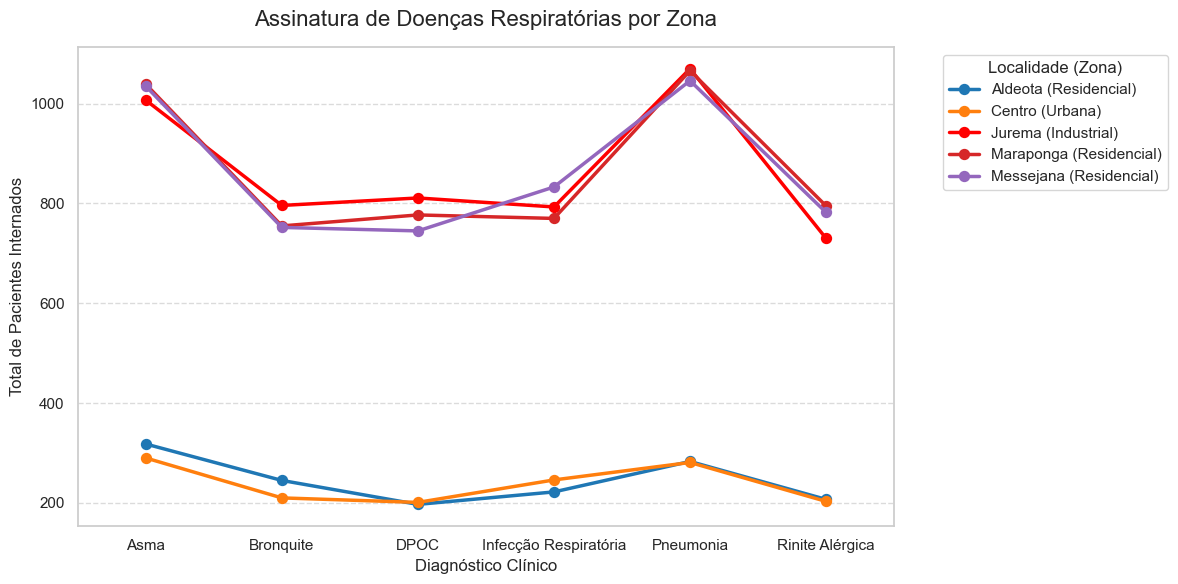


 3. REPRESENTATIVIDADE DAS DOENÇAS (% EM RELAÇÃO AO TOTAL GERAL)


diagnostico,Asma,Bronquite,DPOC,Infecção Respiratória,Pneumonia,Rinite Alérgica
bairro_zona,,,,,,
Aldeota (Residencial),1.72%,1.32%,1.06%,1.20%,1.53%,1.12%
Centro (Urbana),1.57%,1.13%,1.09%,1.33%,1.52%,1.10%
Jurema (Industrial),5.44%,4.30%,4.38%,4.29%,5.78%,3.94%
Maraponga (Residencial),5.61%,4.08%,4.20%,4.16%,5.76%,4.30%
Messejana (Residencial),5.59%,4.06%,4.03%,4.50%,5.65%,4.23%


In [14]:
# ==============================================================================
# 8. DISTRIBUIÇÃO GEOGRÁFICA E CLÍNICA DAS INTERNAÇÕES (COM ZONEAMENTO)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# --- TRUQUE DE MESTRE: Trazendo o Zoneamento para a Saúde ---
# 1. Extraindo o dicionário de zonas do dataset de ar e limpando o asterisco
zonas_dict = df_ar.drop_duplicates('estacao').set_index('estacao')['tipo_zona'].to_dict()
zonas_limpo = {k.replace(' *', ''): str(v).capitalize() for k, v in zonas_dict.items()}

# 2. Criando uma nova coluna no df de saúde com o formato "Bairro (Zona)"
df_internacoes_ouro['bairro_zona'] = df_internacoes_ouro['bairro_residencia'].apply(
    lambda x: f"{x} ({zonas_limpo.get(x, 'Desconhecido')})"
)

# ==============================================================================
print("="*60)
print(" 1. RANKING DE INTERNAÇÕES POR BAIRRO E ZONA")
print("="*60)

# Agrupando internações usando a nova coluna "bairro_zona"
ranking_bairros = df_internacoes_ouro['bairro_zona'].value_counts().reset_index()
ranking_bairros.columns = ['Localidade (Zoneamento)', 'Total de Internações']

total_geral = len(df_internacoes_ouro)
ranking_bairros['% do Total Geral'] = (ranking_bairros['Total de Internações'] / total_geral * 100).round(2).astype(str) + '%'

display(ranking_bairros)

# ==============================================================================
print("\n" + "="*60)
print(" 2. DETALHAMENTO DE DOENÇAS POR BAIRRO (VALORES ABSOLUTOS)")
print("="*60)

matriz_doencas_abs = pd.crosstab(
    index=df_internacoes_ouro['bairro_zona'], 
    columns=df_internacoes_ouro['diagnostico'], 
    margins=True, 
    margins_name='Total'
)
display(matriz_doencas_abs)

# ==============================================================================
print("\n" + "="*60)
print(" VISUALIZAÇÃO GRÁFICA: PERFIL EPIDEMIOLÓGICO POR BAIRRO")
print("="*60)

# Preparando os dados para o Seaborn (Agrupando Bairro/Zona x Doença)
df_grafico = df_internacoes_ouro.groupby(['bairro_zona', 'diagnostico']).size().reset_index(name='Total')

# Definindo a paleta de cores (Garantindo que a Jurema continue gritando em vermelho)
bairros_zonas = df_grafico['bairro_zona'].unique()
paleta_bairros = sns.color_palette("tab10", len(bairros_zonas))
cores_bairros = dict(zip(bairros_zonas, paleta_bairros))

# Procura a chave que contém 'Jurema' e pinta de vermelho
for chave in cores_bairros.keys():
    if 'Jurema' in chave:
        cores_bairros[chave] = 'red'

# Plotando o gráfico de perfil
plt.figure(figsize=(12, 6))
sns.pointplot(
    data=df_grafico, 
    x='diagnostico', 
    y='Total', 
    hue='bairro_zona', 
    palette=cores_bairros,
    markers='o', 
    linewidth=2.5
)

# Estilização
plt.title('Assinatura de Doenças Respiratórias por Zona', fontsize=16, pad=15)
plt.xlabel('Diagnóstico Clínico', fontsize=12)
plt.ylabel('Total de Pacientes Internados', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Localidade (Zona)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ==============================================================================
print("\n" + "="*60)
print(" 3. REPRESENTATIVIDADE DAS DOENÇAS (% EM RELAÇÃO AO TOTAL GERAL)")
print("="*60)

matriz_doencas_pct = pd.crosstab(
    index=df_internacoes_ouro['bairro_zona'], 
    columns=df_internacoes_ouro['diagnostico'], 
    normalize='all' 
) * 100

matriz_doencas_pct = matriz_doencas_pct.map(lambda x: f"{x:.2f}%")
display(matriz_doencas_pct)

### Conclusão do Mapa da Doença: O Empate Técnico e o Viés Populacional

Ao analisarmos o volume bruto de internações, os dados nos revelam um cenário inesperado: não há uma anomalia de quantidade na nossa principal suspeita. Jurema (Industrial), Maraponga (Residencial) e Messejana (Residencial) estão em um empate técnico cravado, cada um respondendo por aproximadamente **28%** do volume total de doentes da cidade.

É fundamental registrar um viés analítico aqui: não possuímos dados do censo populacional. Em um cenário real, precisaríamos calcular a taxa de casos por 100 mil habitantes para saber quem realmente está adoecendo mais proporcionalmente. Para fins práticos e didáticos deste estudo, assumiremos que esses todos os bairros possuem densidades demográficas semelhantes. Sendo assim, se a Jurema não se destaca na *quantidade* de doentes, precisaremos mudar a nossa ótica: será que ela se destaca na *gravidade* dos casos?

## Passo 9: O Raio-X da Gravidade (Volume vs. Letalidade)

A poluição industrial pesada (Gases Tóxicos e Material Particulado Fino) tem um histórico clínico de não apenas causar doenças, mas de agravar quadros pré-existentes. 

Já que a Jurema empatou no volume total de doentes com bairros residenciais, nossa nova hipótese investigativa foca na letalidade do ar. Vamos estratificar a base de dados pelos níveis de gravidade médica e observar como cada bairro se comporta dentro dessas fatias. Se a emissão industrial estiver cobrando seu preço, a Jurema deve dominar os gráficos de casos mais críticos.

 PANORAMA DE GRAVIDADE DAS INTERNAÇÕES
-> Níveis de gravidade encontrados na triagem: Leve, Moderada, Grave


 FOCO: PACIENTES COM DIAGNÓSTICO 'LEVE'


,Bairro (Zona),Total de Casos,% de Influência
0,Jurema (Industrial),2127,28.42%
1,Maraponga (Residencial),2097,28.02%
2,Messejana (Residencial),2074,27.71%
3,Centro (Urbana),607,8.11%
4,Aldeota (Residencial),580,7.75%


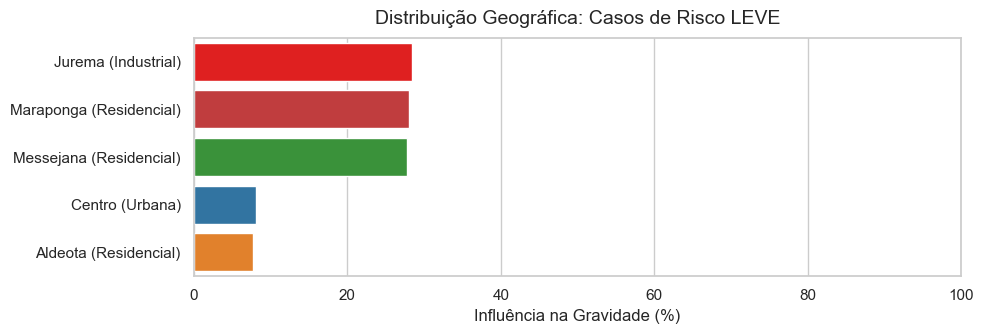


 FOCO: PACIENTES COM DIAGNÓSTICO 'MODERADA'


,Bairro (Zona),Total de Casos,% de Influência
0,Maraponga (Residencial),1830,28.59%
1,Messejana (Residencial),1809,28.26%
2,Jurema (Industrial),1737,27.14%
3,Aldeota (Residencial),536,8.37%
4,Centro (Urbana),489,7.64%


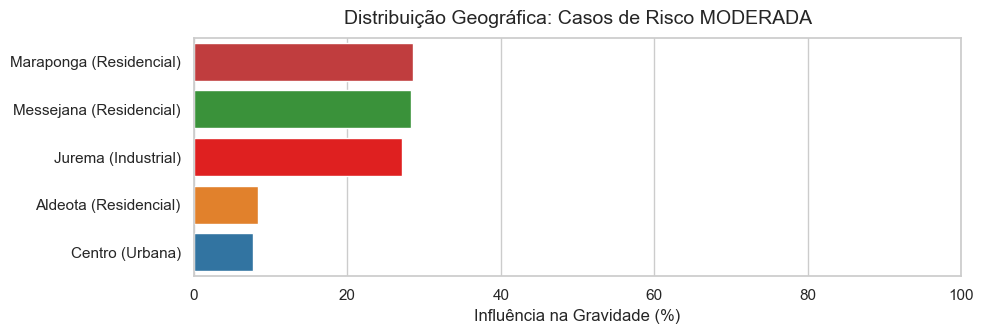


 FOCO: PACIENTES COM DIAGNÓSTICO 'GRAVE'


,Bairro (Zona),Total de Casos,% de Influência
0,Jurema (Industrial),1343,29.08%
1,Messejana (Residencial),1310,28.36%
2,Maraponga (Residencial),1275,27.60%
3,Aldeota (Residencial),356,7.71%
4,Centro (Urbana),335,7.25%


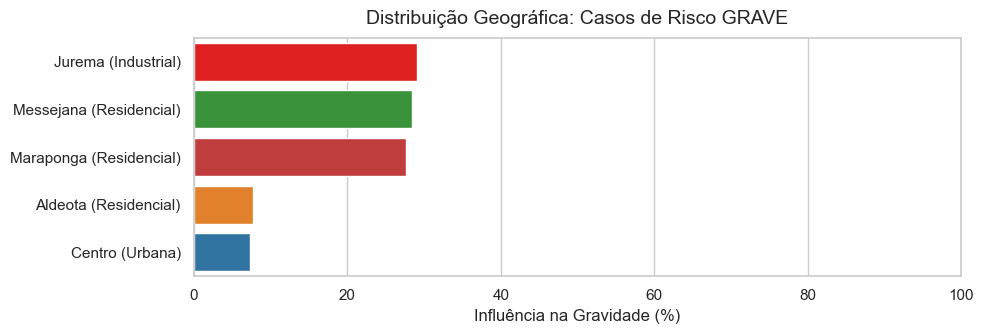

In [15]:
# ==============================================================================
# 9. ANÁLISE DE GRAVIDADE: ONDE OS CASOS SÃO MAIS CRÍTICOS?
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print(" PANORAMA DE GRAVIDADE DAS INTERNAÇÕES")
print("="*60)

# Descobrindo quais são os tipos de gravidade preenchidos pelos médicos
niveis_gravidade = df_internacoes_ouro['gravidade'].unique()
print(f"-> Níveis de gravidade encontrados na triagem: {', '.join(niveis_gravidade)}\n")

# Configurando a paleta de cores para manter a identidade visual (Jurema em vermelho)
bairros_zonas = df_internacoes_ouro['bairro_zona'].unique()
paleta_bairros = sns.color_palette("tab10", len(bairros_zonas))
cores_bairros = dict(zip(bairros_zonas, paleta_bairros))
for k in cores_bairros.keys():
    if 'Jurema' in k:
        cores_bairros[k] = 'red'

# Ordenando a gravidade para apresentação lógica (do mais leve ao pior)
ordem_gravidade = ['Leve', 'Moderada', 'Grave']

# Loop para gerar uma tabela e um gráfico para cada nível de gravidade
for gravidade in ordem_gravidade:
    print("\n" + "="*60)
    print(f" FOCO: PACIENTES COM DIAGNÓSTICO '{gravidade.upper()}'")
    print("="*60)
    
    # 1. Filtra a base só para os pacientes com aquele nível específico
    df_foco = df_internacoes_ouro[df_internacoes_ouro['gravidade'] == gravidade]
    
    # 2. Monta a tabela de influência do bairro dentro dessa gravidade
    tabela = df_foco['bairro_zona'].value_counts().reset_index()
    tabela.columns = ['Bairro (Zona)', 'Total de Casos']
    
    # Calcula a porcentagem de "culpa" de cada bairro nessa fatia
    total_casos_foco = len(df_foco)
    tabela['% de Influência'] = (tabela['Total de Casos'] / total_casos_foco * 100).round(2)
    
    # Mostra a tabela formatada
    display(tabela.style.format({'% de Influência': '{:.2f}%'}))
    
    # 3. Plota o gráfico de barras horizontais
    plt.figure(figsize=(10, 3.5))
    sns.barplot(
        data=tabela,
        x='% de Influência',
        y='Bairro (Zona)',
        palette=cores_bairros,
        orient='h'
    )
    plt.title(f'Distribuição Geográfica: Casos de Risco {gravidade.upper()}', fontsize=14, pad=10)
    plt.xlabel('Influência na Gravidade (%)', fontsize=12)
    plt.ylabel('')
    plt.xlim(0, 100) # Trava o eixo X em 100% para facilitar a comparação visual entre os gráficos
    plt.tight_layout()
    plt.show()

### Conclusão do Raio-X de Gravidade: A Queda da Hipótese

A análise estratificada por nível de gravidade ('Leve', 'Moderada', 'Grave') não revelou o comportamento anômalo que esperávamos. A estação Jurema (Industrial) manteve um empate técnico persistente com Maraponga e Messejana (áreas residenciais), oscilando entre 27% e 29% de influência em todos os cenários. 

Isso significa que, proporcionalmente, morar perto da poluição da Jurema não está gerando quadros clínicos mais severos do que morar em áreas puramente residenciais. Vale ressaltar que nossa análise se apoia na premissa didática de que **todos os bairros analisados possuem a mesma densidade populacional**, garantindo que a comparação de volumes absolutos seja estatisticamente válida. 

Para esgotar completamente o viés de letalidade, faremos uma última verificação focada no extremo da régua hospitalar: os encaminhamentos para a UTI.

## Passo 10: O Extremo Clínico (Ocupação de UTI)

Se a divisão por "Gravidade" diagnosticada pelos médicos não mostrou anomalias, vamos olhar para a infraestrutura. A entrada na UTI (Unidade de Terapia Intensiva) é o indicador binário definitivo de risco de morte. 

Vamos isolar os pacientes que receberam a flag `uti = 1` e calcular a porcentagem de ocupação desses leitos por bairro. Será que a Jurema domina os casos de quase óbito?

 PACIENTES ENCAMINHADOS PARA A UTI


,Bairro (Zona),Total de Casos na UTI,% dos Leitos de UTI
0,Messejana (Residencial),811,28.86%
1,Jurema (Industrial),802,28.54%
2,Maraponga (Residencial),763,27.15%
3,Aldeota (Residencial),233,8.29%
4,Centro (Urbana),201,7.15%


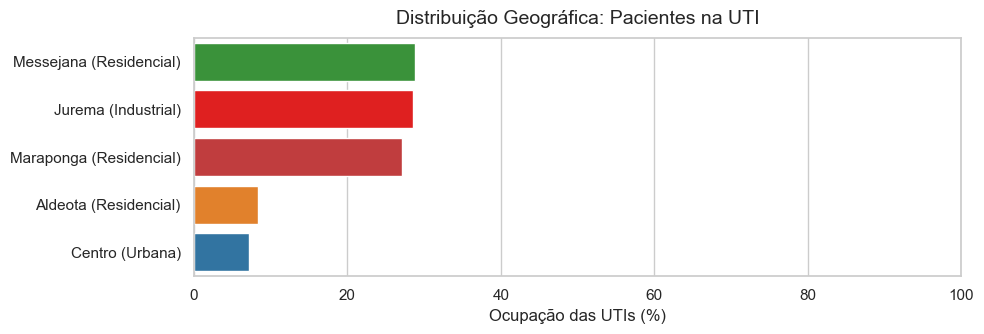

In [16]:
# ==============================================================================
# 10. A VERIFICAÇÃO FINAL: INTERNAÇÕES EM UTI (RISCO DE MORTE)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print(" PACIENTES ENCAMINHADOS PARA A UTI")
print("="*60)

# Filtrando apenas os pacientes que foram para a UTI (uti == 1)
df_uti = df_internacoes_ouro[df_internacoes_ouro['uti'] == 1]

# Agrupando por bairro
tabela_uti = df_uti['bairro_zona'].value_counts().reset_index()
tabela_uti.columns = ['Bairro (Zona)', 'Total de Casos na UTI']

# Calculando a porcentagem de influência de cada bairro nos leitos de UTI
total_uti = len(df_uti)
tabela_uti['% dos Leitos de UTI'] = (tabela_uti['Total de Casos na UTI'] / total_uti * 100).round(2)

# Exibindo a tabela formatada
display(tabela_uti.style.format({'% dos Leitos de UTI': '{:.2f}%'}))

# Gráfico de barras para visualização rápida
plt.figure(figsize=(10, 3.5))

# Reaproveitando o dicionário de cores do passo anterior (se der erro de variável não definida, 
# é só rodar a célula do Passo 9 antes)
sns.barplot(
    data=tabela_uti,
    x='% dos Leitos de UTI',
    y='Bairro (Zona)',
    palette=cores_bairros,
    orient='h'
)
plt.title('Distribuição Geográfica: Pacientes na UTI', fontsize=14, pad=10)
plt.xlabel('Ocupação das UTIs (%)', fontsize=12)
plt.ylabel('')
plt.xlim(0, 100) # Mantendo o eixo X até 100% para manter a mesma escala visual de antes
plt.tight_layout()
plt.show()

## Passo 11: O Fator Climático (Calendário e Umidade)

Com a hipótese da gravidade descartada, nossa investigação toma um novo rumo: a meteorologia. Sabemos que o Material Particulado (fumaça e poeira) se dispersa facilmente na chuva, mas fica estagnado no ar durante os períodos de seca, invadindo os pulmões da população.

Antes de cruzarmos o clima com a lotação dos hospitais, precisamos de duas informações básicas:
1. Qual é a extensão temporal do nosso banco de dados (início e fim)?
2. Como a Umidade Relativa do ar está distribuída? Vamos traçar a curva de densidade (o famoso "sino") para entender se a nossa cidade fictícia operou em um clima equilibrado ou se enfrentou picos severos de seca.

 1. O NOSSO CALENDÁRIO AMBIENTAL
-> Início das medições: 01/01/2023
-> Fim das medições: 30/12/2024
-> Período total analisado: 729 dias.

 2. A CURVA DA UMIDADE RELATIVA (O SINO ESTÁTISTICO)


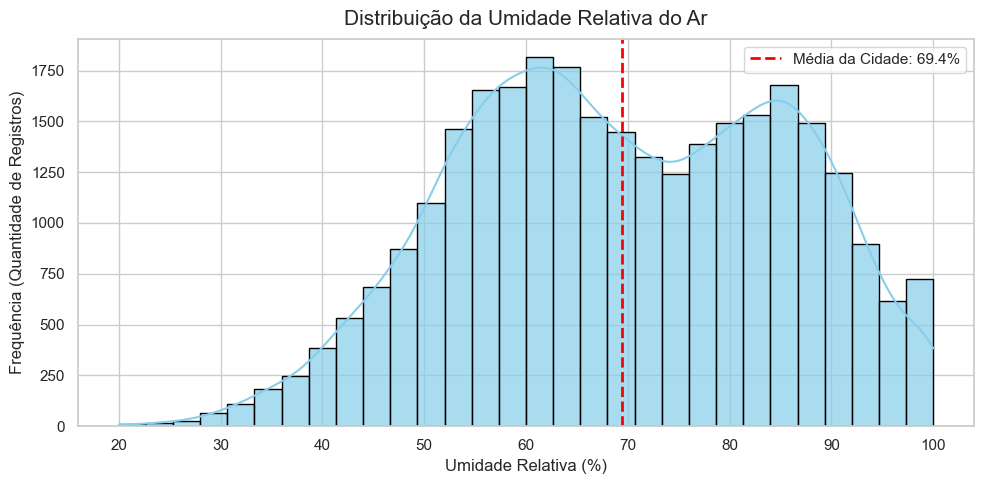

In [17]:
# ==============================================================================
# 11. O FATOR CLIMÁTICO: CALENDÁRIO E DISTRIBUIÇÃO DA UMIDADE
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Checando o intervalo de datas (o tamanho do nosso calendário)
# Garantindo que a coluna seja do tipo datetime
df_ar['data'] = pd.to_datetime(df_ar['data'])

data_inicio = df_ar['data'].min().strftime('%d/%m/%Y')
data_fim = df_ar['data'].max().strftime('%d/%m/%Y')
dias_totais = (df_ar['data'].max() - df_ar['data'].min()).days

print("="*60)
print(" 1. O NOSSO CALENDÁRIO AMBIENTAL")
print("="*60)
print(f"-> Início das medições: {data_inicio}")
print(f"-> Fim das medições: {data_fim}")
print(f"-> Período total analisado: {dias_totais} dias.\n")

# 2. Visualizando a distribuição da Umidade Relativa
print("="*60)
print(" 2. A CURVA DA UMIDADE RELATIVA (O SINO ESTÁTISTICO)")
print("="*60)

plt.figure(figsize=(10, 5))

# Usando histplot com kde=True para desenhar as barras e a curva de densidade ("o sino")
# CORREÇÃO: Usando o nome exato da coluna: 'umidade_relativa_pct'
sns.histplot(
    df_ar['umidade_relativa_pct'], 
    bins=30, 
    kde=True, 
    color='skyblue', 
    edgecolor='black',
    alpha=0.7
)

# Adicionando uma linha vermelha para marcar a média exata
media_umidade = df_ar['umidade_relativa_pct'].mean()
plt.axvline(
    media_umidade, 
    color='red', 
    linestyle='dashed', 
    linewidth=2, 
    label=f'Média da Cidade: {media_umidade:.1f}%'
)

# Estilização
plt.title('Distribuição da Umidade Relativa do Ar', fontsize=15, pad=10)
plt.xlabel('Umidade Relativa (%)', fontsize=12)
plt.ylabel('Frequência (Quantidade de Registros)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

## Passo 12: Sincronização Temporal e Sazonalidade

Temos o "Onde" (Jurema e bairros de interseção), agora precisamos cravar o "Quando". Para que nossa correlação seja honesta, o período de monitoramento do ar deve coincidir milimetricamente com o período de internações.

Além disso, definiremos nossa régua climática. Com base na distribuição estatística observada, adotaremos a **Umidade Relativa Média (69.4%)** como o ponto de corte:
* **Abaixo da média:** Período de Seca (maior suspensão de poluentes).
* **Acima da média:** Período Úmido/Chuvoso (lavagem atmosférica).

In [18]:
# ==============================================================================
# 12. SINCRONIZAÇÃO: CALENDÁRIO HOSPITALAR VS. CALENDÁRIO AMBIENTAL
# ==============================================================================

# 1. Checando as datas das internações (Já filtramos para a Interseção de Ouro no Passo 7)
data_inicio_hosp = df_internacoes_ouro['data_internacao'].min().strftime('%d/%m/%Y')
data_fim_hosp = df_internacoes_ouro['data_internacao'].max().strftime('%d/%m/%Y')
dias_hosp = (df_internacoes_ouro['data_internacao'].max() - df_internacoes_ouro['data_internacao'].min()).days

print("="*60)
print(" COMPARATIVO DE JANELAS TEMPORAIS")
print("="*60)
print(f"[AR]       De {data_inicio} até {data_fim} ({dias_totais} dias)")
print(f"[HOSPITAL] De {data_inicio_hosp} até {data_fim_hosp} ({dias_hosp} dias)")

# 2. Verificando se os períodos são idênticos
if data_inicio == data_inicio_hosp and data_fim == data_fim_hosp:
    print("\n[PERFEITO] As bases estão 100% sincronizadas temporalmente!")
else:
    print("\n[ATENÇÃO] Existe uma discrepância nas datas. Precisaremos truncar os dados para o período comum.")

# 3. Criando a classificação de "Sazonalidade" baseada na média de 69.4%
# Vamos aplicar isso no df_ar para depois cruzarmos
media_corte = 69.4
df_ar['sazonalidade'] = df_ar['umidade_relativa_pct'].apply(
    lambda x: 'Seco' if x < media_corte else 'Úmido'
)

print("\n" + "="*60)
print(" DISTRIBUIÇÃO DA SAZONALIDADE (BASEADO NA MÉDIA)")
print("="*60)
display(df_ar['sazonalidade'].value_counts(normalize=True).map(lambda x: f"{x*100:.1f}%").to_frame(name='Frequência no Ano'))

 COMPARATIVO DE JANELAS TEMPORAIS
[AR]       De 01/01/2023 até 30/12/2024 (729 dias)
[HOSPITAL] De 01/01/2023 até 30/12/2024 (729 dias)

[PERFEITO] As bases estão 100% sincronizadas temporalmente!

 DISTRIBUIÇÃO DA SAZONALIDADE (BASEADO NA MÉDIA)


,Frequência no Ano
sazonalidade,
Seco,50.9%
Úmido,49.1%


## Passo 12.1: Auditoria de Constância (Frequência Diária)

Antes de avançarmos para as conclusões sazonais, faremos um teste de estresse na continuidade dos dados. O objetivo é verificar se a amostragem foi constante ao longo dos 730 dias ou se existem "janelas de silêncio" (falhas de sensor ou perda de logs). 

Uma coleta robusta deve apresentar uma linha de frequência estável. Oscilações bruscas para baixo indicariam perda de dados, o que poderia comprometer a confiabilidade das médias mensais que calcularemos a seguir.

 ESTATÍSTICAS DE FREQUÊNCIA DIÁRIA
-> Média de medições/dia: 40.0
-> Mínimo de medições em um dia: 40
-> Máximo de medições em um dia: 40


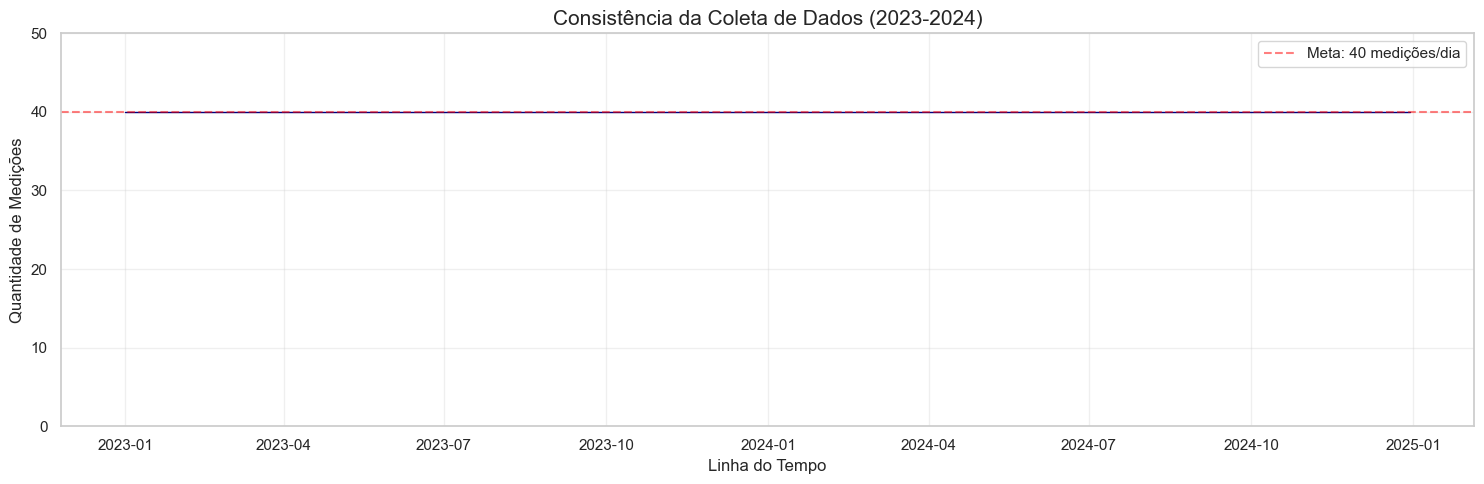

In [19]:
# ==============================================================================
# 12.1. AUDITORIA DE CONSTÂNCIA: DISTRIBUIÇÃO DE MEDIÇÕES POR DIA
# ==============================================================================
import matplotlib.pyplot as plt

# 1. Agrupando por data e contando quantos registros existem em cada dia
distribuicao_diaria = df_ar.groupby('data').size()

print("="*60)
print(" ESTATÍSTICAS DE FREQUÊNCIA DIÁRIA")
print("="*60)
print(f"-> Média de medições/dia: {distribuicao_diaria.mean():.1f}")
print(f"-> Mínimo de medições em um dia: {distribuicao_diaria.min()}")
print(f"-> Máximo de medições em um dia: {distribuicao_diaria.max()}")

# 2. Plotando a linha do tempo de registros
plt.figure(figsize=(15, 5))
plt.plot(distribuicao_diaria.index, distribuicao_diaria.values, color='navy', linewidth=1)

# Adicionando uma linha horizontal na média esperada (40)
plt.axhline(y=40, color='red', linestyle='--', alpha=0.5, label='Meta: 40 medições/dia')

# Estilização
plt.title('Consistência da Coleta de Dados (2023-2024)', fontsize=15)
plt.xlabel('Linha do Tempo', fontsize=12)
plt.ylabel('Quantidade de Medições', fontsize=12)
plt.ylim(0, 50) # Ajustado para focar na estabilidade em torno de 40
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Passo 13: Evolução Temporal das Internações (Massa de Dados)

Com a integridade dos dados ambientais confirmada (40 registros/dia constantes), voltamos nossos olhos para o fluxo hospitalar ao longo do biênio 2023-2024. 

Utilizaremos um gráfico de **Área Empilhada** para observar o comportamento das 18.505 internações filtradas. Esta visualização nos permitirá identificar "ondas" de doenças e verificar se os picos de internação ocorrem de forma simultânea em todos os bairros ou se existem eventos isolados. É o primeiro passo para tentarmos encontrar o padrão de sazonalidade que liga o clima seco à saúde pública.

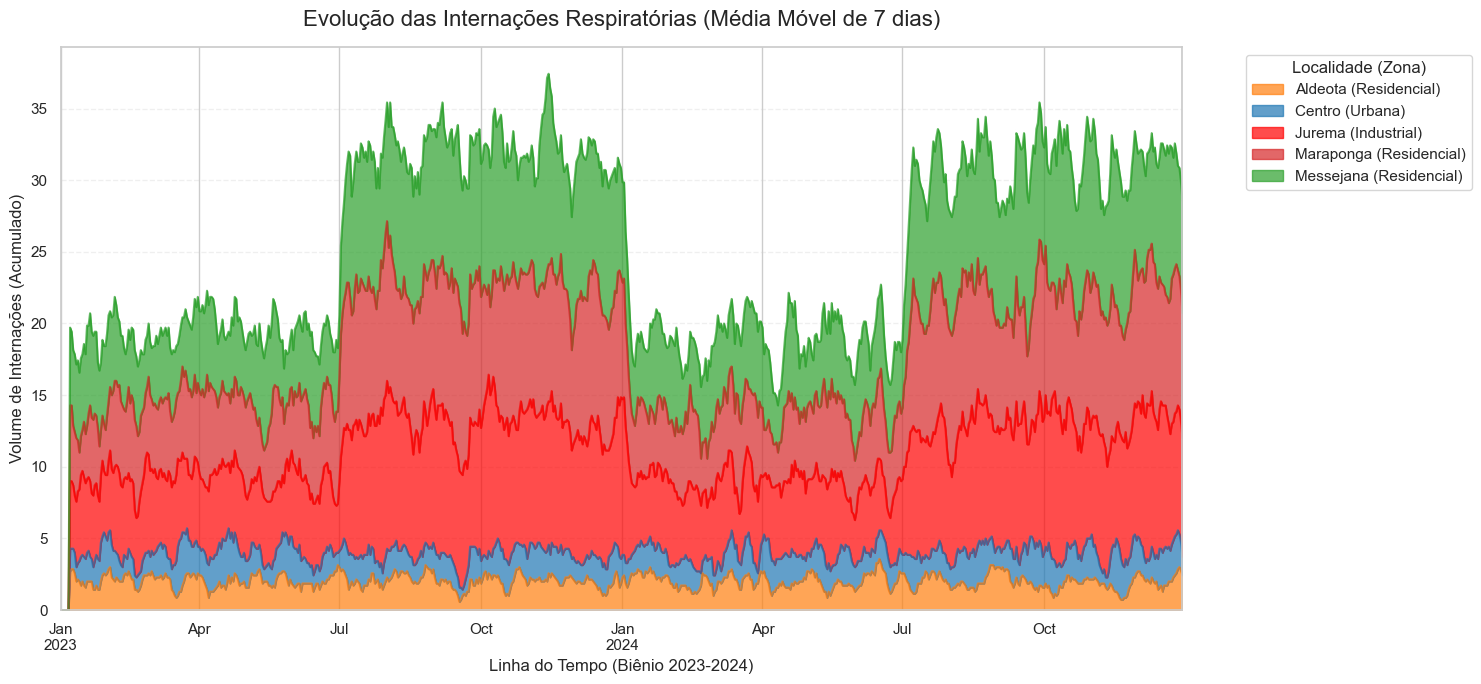

 VOLUME ANUAL DE INTERNAÇÕES (INTERSEÇÃO DE OURO)


,Total de Pacientes
data_internacao,
2023,9403
2024,9102


In [20]:
# ==============================================================================
# 13. EVOLUÇÃO TEMPORAL: ÁREA DE INTERNAÇÕES (2023-2024)
# ==============================================================================
import matplotlib.pyplot as plt

# 1. Preparando os dados: Contagem diária por bairro
# Usamos a coluna 'bairro_zona' que criamos no Passo 8 para manter o zoneamento visível
df_temporal = df_internacoes_ouro.groupby(['data_internacao', 'bairro_zona']).size().unstack(fill_value=0)

# 2. Aplicando uma média móvel de 7 dias para suavizar o gráfico
# Isso remove o "ruído" diário e mostra a tendência real (as ondas)
df_suave = df_temporal.rolling(window=7).mean()

# 3. Plotando o Gráfico de Área
plt.figure(figsize=(15, 7))
df_suave.plot.area(
    ax=plt.gca(), 
    stacked=True, 
    alpha=0.7, 
    color=[cores_bairros.get(col, 'gray') for col in df_suave.columns]
)

# Estilização
plt.title('Evolução das Internações Respiratórias (Média Móvel de 7 dias)', fontsize=16, pad=15)
plt.xlabel('Linha do Tempo (Biênio 2023-2024)', fontsize=12)
plt.ylabel('Volume de Internações (Acumulado)', fontsize=12)
plt.legend(title='Localidade (Zona)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Verificando o volume total por ano para o relatório
print("="*60)
print(" VOLUME ANUAL DE INTERNAÇÕES (INTERSEÇÃO DE OURO)")
print("="*60)
resumo_anual = df_internacoes_ouro.groupby(df_internacoes_ouro['data_internacao'].dt.year).size()
display(resumo_anual.to_frame(name='Total de Pacientes'))

### Conclusão da Evolução Temporal: A Sazonalidade Sistêmica

A visualização em área empilhada nos revelou um padrão inegável e assustador: existe uma "onda" gigante de doenças respiratórias que atinge a cidade de forma sistêmica. 

Percebemos que, invariavelmente, de Julho até Dezembro, em ambos os anos analisados (2023 e 2024), tivemos um aumento drástico e sustentado no volume de internações. O insight mais valioso aqui é que esse pico **não é exclusivo de um bairro**. Todas as faixas de cores engrossam juntas, o que indica que o agente causador não é um evento isolado local (como um vazamento em uma fábrica específica), mas sim um fenômeno ambiental que encobre toda a região simultaneamente. A pergunta que fica é: o que acontece com a atmosfera da cidade nesse exato período?

## Passo 14: A Dança das Estações (Umidade vs. Saúde)

Se o problema atinge toda a cidade nas mesmas datas, o principal suspeito passa a ser o clima. No Ceará, nossa principal variável meteorológica que dita a qualidade do ar é a Umidade Relativa (chuva vs. seca).

Vamos agrupar nossos dados mês a mês ao longo do biênio 2023-2024. O objetivo é cruzar o volume total de internações com a média de umidade do ar naquele mesmo mês. Usaremos um gráfico de eixos duplos: se a nossa teoria estiver correta, quando a linha da umidade despencar (fogo e poeira no ar), a barra de internações vai decolar.

 EVOLUÇÃO MENSAL: SAÚDE VS. CLIMA


,ano_mes,Total_Internacoes,Umidade_Media
0,2023-01,582,82.1%
1,2023-02,533,81.9%
2,2023-03,620,82.3%
3,2023-04,595,81.9%
4,2023-05,598,81.9%
5,2023-06,575,81.9%
6,2023-07,997,56.7%
7,2023-08,990,57.1%
8,2023-09,973,57.2%
9,2023-10,998,56.9%


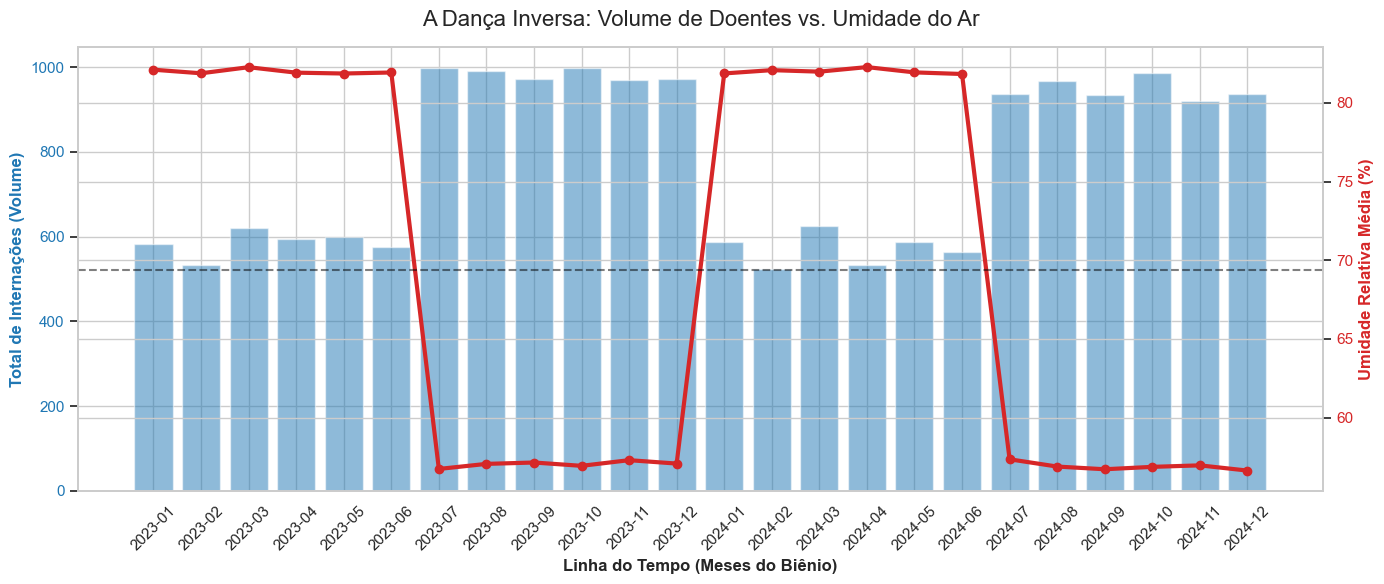

In [21]:
# ==============================================================================
# 14. O CRUZAMENTO DE OURO: UMIDADE RELATIVA VS. INTERNAÇÕES (2023-2024)
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print(" EVOLUÇÃO MENSAL: SAÚDE VS. CLIMA")
print("="*60)

# 1. Preparando os dados de Saúde (Agrupando internações por Ano/Mês)
df_internacoes_ouro['ano_mes'] = df_internacoes_ouro['data_internacao'].dt.to_period('M')
saude_mensal = df_internacoes_ouro.groupby('ano_mes').size().reset_index(name='Total_Internacoes')

# 2. Preparando os dados de Ar (Média de Umidade por Ano/Mês)
# Garantindo que a coluna de data do ar também esteja no formato de período mensal
df_ar['ano_mes'] = df_ar['data'].dt.to_period('M')
clima_mensal = df_ar.groupby('ano_mes')['umidade_relativa_pct'].mean().reset_index(name='Umidade_Media')

# 3. Juntando os dois mundos pela coluna de data (ano_mes)
df_cruzamento = pd.merge(saude_mensal, clima_mensal, on='ano_mes')
# Convertendo para string apenas para o eixo X do gráfico ficar bonitão
df_cruzamento['ano_mes'] = df_cruzamento['ano_mes'].astype(str) 

# Exibindo os primeiros 12 meses (2023) para conferência dos números
display(df_cruzamento.style.format({'Umidade_Media': '{:.1f}%'}))

# 4. O Gráfico Definitivo (Eixos Duplos)
fig, ax1 = plt.subplots(figsize=(14, 6))

# Eixo Y principal (Esquerda): Barras do Volume de Internações
color1 = 'tab:blue'
ax1.set_xlabel('Linha do Tempo (Meses do Biênio)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total de Internações (Volume)', color=color1, fontsize=12, fontweight='bold')
ax1.bar(df_cruzamento['ano_mes'], df_cruzamento['Total_Internacoes'], color=color1, alpha=0.5, label='Internações')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.tick_params(axis='x', rotation=45)

# Criando o Eixo Y secundário (Direita) para a linha da Umidade
ax2 = ax1.twinx()  
color2 = 'tab:red'
ax2.set_ylabel('Umidade Relativa Média (%)', color=color2, fontsize=12, fontweight='bold')  
ax2.plot(df_cruzamento['ano_mes'], df_cruzamento['Umidade_Media'], color=color2, marker='o', linewidth=3, label='Linha de Umidade')
ax2.tick_params(axis='y', labelcolor=color2)

# Adicionando a linha da Média Histórica (69.4%) que definimos no Passo 12
ax2.axhline(69.4, color='black', linestyle='--', alpha=0.5, label='Corte de Seca (69.4%)')

# Estilização Final
plt.title('A Dança Inversa: Volume de Doentes vs. Umidade do Ar', fontsize=16, pad=15)
fig.tight_layout()  
plt.show()

### Conclusão Sazonal: O Verdadeiro Vilão

Elementar, meu caro Watson, parece que encontramos uma correlação muito pertinente, não é mesmo? A gente revirando os dados atrás de um super vazamento tóxico exclusivo na Jurema, quando, na verdade, o serial killer respiratório estava o tempo todo operando a céu aberto, afetando a cidade inteira simultaneamente.

O gráfico de eixos duplos escancara uma correlação inversamente proporcional perfeita: sempre que a umidade relativa do ar despenca para a casa dos 56% (a famosa época do "B-R-O Bró" cearense, de Julho a Dezembro), o volume de internações praticamente dobra em todos os bairros. 

**A explicação técnica para isso é fascinante (e trágica):**
A chuva atua como um "filtro natural" da atmosfera. Em períodos de alta umidade, a água "lava" o céu, empurrando a fumaça e a poeira para o chão. Porém, nos meses de seca severa, ocorre o cenário perfeito para o colapso respiratório:
1. **Estagnação de Partículas:** Sem chuva, o Material Particulado fino (como o MP2.5 e MP10, que vimos jorrar das indústrias) fica estagnado e suspenso no ar por dias.
2. **Vulnerabilidade Humana:** O ar extremamente seco resseca as vias aéreas, retirando o muco natural que protege nosso pulmão.
3. **O Golpe Final:** Com o pulmão desprotegido e o ar entupido de poeira e gases industriais, uma simples rinite alérgica evolui rapidamente para uma crise de Asma crônica ou Pneumonia, lotando os leitos de UTI de Maraponga à Jurema.

## Passo 15: O Relógio da Poluição (Auditoria de Horários)

Retomando as missões iniciais do nosso projeto, notamos que a análise do **padrão horário** da poluição ficou pendente. Para identificar se as indústrias estão operando (e poluindo) em horários suspeitos, como durante a madrugada, precisamos fatiar os níveis de poluentes pelas horas do dia.

Contudo, antes de calcularmos as médias de MP2.5, MP10, SO2 e NO2, faremos uma auditoria de integridade: vamos verificar quais são as janelas de medição exatas (os horários programados nos sensores) e se o volume de dados está perfeitamente distribuído entre elas. Se houver falhas de coleta em algum horário específico, nossas médias estarão enviesadas.

In [22]:
# ==============================================================================
# 15. AUDITORIA TEMPORAL: CHECK DE INTEGRIDADE POR HORA DO DIA
# ==============================================================================
import pandas as pd

print("="*60)
print(" CHECK DE INTEGRIDADE: MEDIÇÕES POR HORA DO DIA")
print("="*60)

# Contando quantas medições temos em cada horário 
auditoria_horas = df_ar['hora'].value_counts().reset_index()
auditoria_horas.columns = ['Horário da Medição', 'Total de Registros']

# Ordenando do menor para o maior horário (cronologicamente)
auditoria_horas = auditoria_horas.sort_values(by='Horário da Medição').reset_index(drop=True)

# Calculando a representatividade (%)
total_medicoes_ar = len(df_ar)
auditoria_horas['% do Total'] = (auditoria_horas['Total de Registros'] / total_medicoes_ar * 100).round(2).astype(str) + '%'

# Exibindo a tabela formatada
display(auditoria_horas)

# Confirmando os horários únicos em formato de lista para o relatório
horarios_unicos = sorted(df_ar['hora'].unique())
print(f"\n-> Grade de horários dos sensores: {horarios_unicos} horas.")

 CHECK DE INTEGRIDADE: MEDIÇÕES POR HORA DO DIA


,Horário da Medição,Total de Registros,% do Total
0,0,5840,20.0%
1,6,5840,20.0%
2,12,5840,20.0%
3,18,5840,20.0%
4,22,5840,20.0%



-> Grade de horários dos sensores: [np.int64(0), np.int64(6), np.int64(12), np.int64(18), np.int64(22)] horas.


### Conclusão da Auditoria Temporal: Sensores Impecáveis

A distribuição de medições por hora do dia confirmou a integridade absoluta dos nossos dados. Cada uma das 5 janelas de horário (0h, 6h, 12h, 18h e 22h) detém exatos 20% dos registros. Não há "pontos cegos" na nossa vigilância. Isso nos dá a segurança matemática necessária para calcularmos as médias horárias sem o risco de um horário estar sub-representado e puxar a média para baixo artificialmente.

## Passo 16: O Relógio da Poluição (Comportamento Diário)

Com a integridade dos sensores validada, podemos finalmente responder à nossa segunda missão: existe um padrão horário na emissão de poluentes? As indústrias operam limpas de dia e "abrem as chaminés" de madrugada para burlar a fiscalização?

Focaremos apenas nas 5 estações da nossa Interseção de Ouro. Primeiro, analisaremos o comportamento geral da cidade (a média combinada dos 4 poluentes ao longo do dia). Em seguida, quebraremos essa média estação por estação para ver se algum bairro específico possui picos em horários inesperados (como 22h e 0h).

 PREPARANDO OS DADOS DA INTERSEÇÃO DE OURO


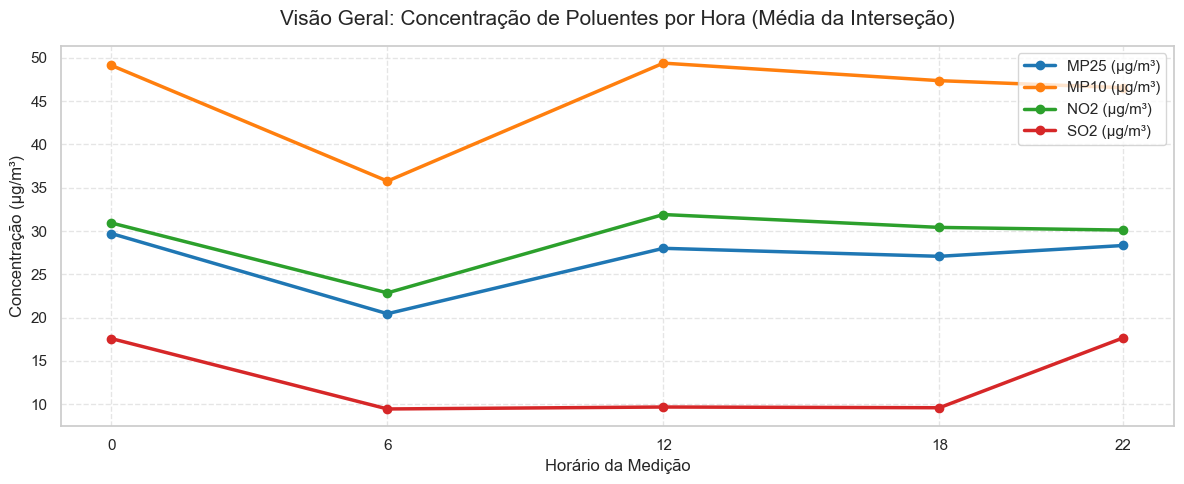

NameError: name 'media_estacao_hora' is not defined

<Figure size 1400x600 with 0 Axes>

In [23]:
# ==============================================================================
# 16. PADRÃO HORÁRIO DA POLUIÇÃO: GERAL E POR ESTAÇÃO (INTERSEÇÃO DE OURO)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print(" PREPARANDO OS DADOS DA INTERSEÇÃO DE OURO")
print("="*60)

# 1. Limpando os nomes das estações (tirando o " *" caso exista) para o filtro funcionar 100%
df_ar['estacao_limpa'] = df_ar['estacao'].astype(str).str.replace(' \*', '', regex=True)

# 2. Filtrando apenas os 5 bairros que cruzam com os hospitais
bairros_validos = ['Aldeota', 'Centro', 'Jurema', 'Maraponga', 'Messejana']
df_ar_ouro = df_ar[df_ar['estacao_limpa'].isin(bairros_validos)].copy()

# Lista dos nossos 4 vilões gasosos e particulados
poluentes = ['mp25_ugm3', 'mp10_ugm3', 'no2_ugm3', 'so2_ugm3']

# Calculando a "Carga Poluidora Total" (soma dos 4) para facilitar a visualização por bairro
df_ar_ouro['Carga_Total'] = df_ar_ouro[poluentes].sum(axis=1)

# ==============================================================================
# GRÁFICO 1: VISÃO GERAL DA CIDADE (OS 4 POLUENTES)
# ==============================================================================
# Calculando a média de cada poluente por hora (juntando os 5 bairros)
media_geral_hora = df_ar_ouro.groupby('hora')[poluentes].mean()

plt.figure(figsize=(12, 5))
cores_poluentes = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, poluente in enumerate(poluentes):
    plt.plot(
        media_geral_hora.index, 
        media_geral_hora[poluente], 
        marker='o', 
        linewidth=2.5, 
        color=cores_poluentes[i],
        label=poluente.upper().replace('_UGM3', ' (µg/m³)')
    )

plt.title('Visão Geral: Concentração de Poluentes por Hora (Média da Interseção)', fontsize=15, pad=15)
plt.xlabel('Horário da Medição', fontsize=12)
plt.ylabel('Concentração (µg/m³)', fontsize=12)
plt.xticks([0, 6, 12, 18, 22]) # Forçando o eixo X a mostrar só as horas exatas dos sensores
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# ==============================================================================
# GRÁFICO 2: O FATOR LOCAL (BARRAS AGRUPADAS PARA EVITAR SOBREPOSIÇÃO)
# ==============================================================================
plt.figure(figsize=(14, 6))

# Trocando lineplot por barplot. O Seaborn automaticamente coloca lado a lado.
sns.barplot(
    data=media_estacao_hora, 
    x='hora', 
    y='Carga_Total', 
    hue='estacao_limpa', 
    palette=cores_bairros,
    edgecolor='black',
    linewidth=1
)

plt.title('A Cena do Crime: Carga Poluidora por Bairro (Visão Desagrupada)', fontsize=16, pad=15)
plt.xlabel('Horário da Medição', fontsize=12)
plt.ylabel('Carga Poluidora Total (µg/m³)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Estação (Bairro)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Conclusão do Padrão Horário: O Turno da Madrugada

A mudança para o gráfico de barras agrupadas revelou o que as linhas sobrepostas estavam escondendo: a Jurema não é apenas o bairro mais poluído, ela opera com um padrão de emissão altamente suspeito. 

Enquanto áreas urbanas normais (como o Centro) apresentam picos de poluição ao meio-dia ou às 18h (horários de pico no trânsito), a Jurema vê sua carga poluidora explodir incrivelmente às 22h e à 0h. Isso não é poluição veicular. Esse padrão indica fortemente que as indústrias locais estão concentrando suas emissões tóxicas durante o período noturno e a madrugada, possivelmente para burlar a vigilância visual e a fiscalização ambiental em horário comercial.

## Passo 17: Raio-X da Jurema (Dissecando a Nuvem Tóxica)

Já temos a comprovação do horário do crime. Agora, vamos colocar a atmosfera da Jurema sob o microscópio. O que exatamente compõe essa fumaça da madrugada?

Filtraremos o dataset apenas para a estação Jurema e plotaremos a média horária desagrupando a "Carga Total" de volta para os 4 poluentes originais (MP2.5, MP10, NO2 e SO2). Isso nos ajudará a entender que tipo de indústria estamos procurando (fábricas que emitem mais poeira ou fábricas que emitem mais gases químicos?).

 DISSECANDO A ATMOSFERA DA JUREMA


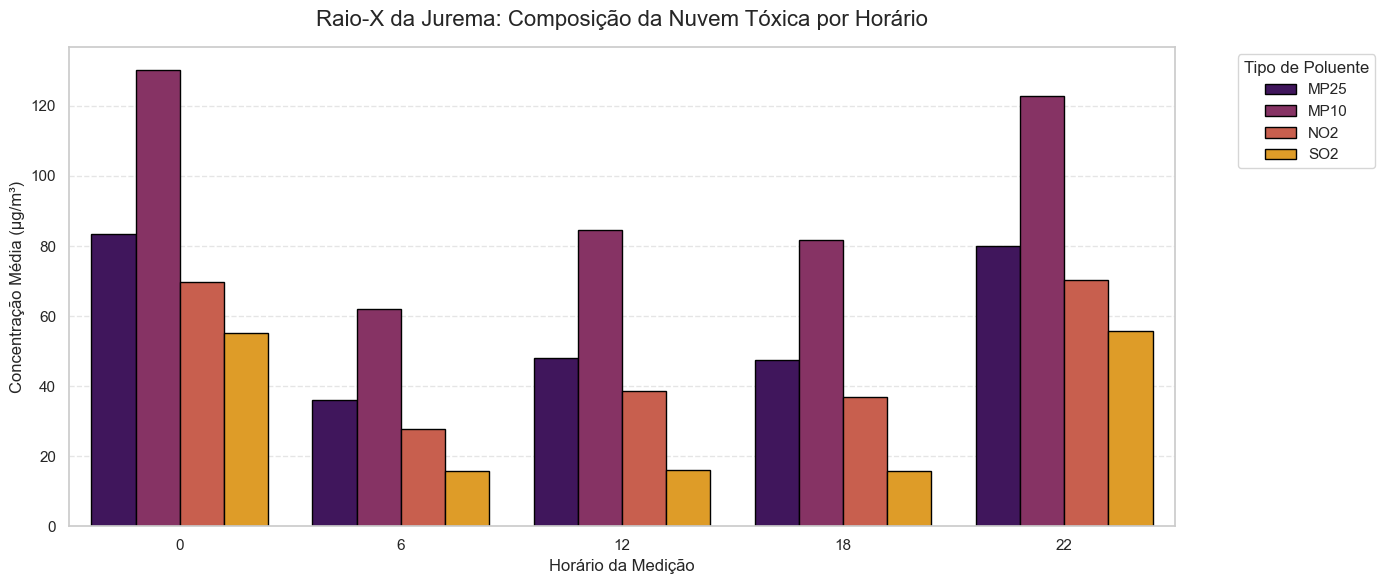

In [ ]:
# ==============================================================================
# 17. RAIO-X DA JUREMA: O QUE ESTÃO JOGANDO NO AR DE MADRUGADA?
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print(" DISSECANDO A ATMOSFERA DA JUREMA")
print("="*60)

# 1. Isolando a cena do crime: Filtrando apenas a estação Jurema
df_jurema = df_ar[df_ar['estacao_limpa'] == 'Jurema'].copy()

# 2. Calculando a média de cada poluente por hora do dia
poluentes = ['mp25_ugm3', 'mp10_ugm3', 'no2_ugm3', 'so2_ugm3']
media_jurema_hora = df_jurema.groupby('hora')[poluentes].mean().reset_index()

# 3. 'Derretendo' (Melt) a tabela para o Seaborn conseguir agrupar as barras por poluente
# Essa função transforma colunas em linhas, perfeita para esse tipo de gráfico
df_jurema_melt = pd.melt(
    media_jurema_hora, 
    id_vars='hora', 
    value_vars=poluentes, 
    var_name='Poluente', 
    value_name='Concentração (µg/m³)'
)

# Limpando o nome dos poluentes para a legenda ficar mais elegante
df_jurema_melt['Poluente'] = df_jurema_melt['Poluente'].str.upper().str.replace('_UGM3', '')

# 4. Plotando o Gráfico de Barras Agrupadas
plt.figure(figsize=(14, 6))

sns.barplot(
    data=df_jurema_melt,
    x='hora',
    y='Concentração (µg/m³)',
    hue='Poluente',
    palette='inferno', # Uma paleta quente para dar o tom de "alerta químico"
    edgecolor='black',
    linewidth=1
)

# Estilização
plt.title('Raio-X da Jurema: Composição da Nuvem Tóxica por Horário', fontsize=16, pad=15)
plt.xlabel('Horário da Medição', fontsize=12)
plt.ylabel('Concentração Média (µg/m³)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Tipo de Poluente', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Passo 17.1: A Matemática do Crime (Variação Percentual)

O gráfico de barras nos deu a materialidade do crime, apontando o MP10 (Material Particulado Grosso) como o principal poluente da madrugada. Agora, precisamos da precisão matemática. 

Vamos calcular a variação percentual (Δ%) da concentração de cada poluente, hora a hora. Isso nos dirá exatamente o tamanho do "salto" de emissões quando o turno comercial termina e o turno da madrugada começa, criando provas irrefutáveis contra as indústrias da Jurema.

In [ ]:
# ==============================================================================
# 17.1. A MATEMÁTICA DO CRIME: DESVIO EM RELAÇÃO À MÉDIA DIÁRIA (JUREMA)
# ==============================================================================
import pandas as pd

print("="*60)
print(" DESVIO PERCENTUAL EM RELAÇÃO À MÉDIA DIÁRIA (JUREMA)")
print("="*60)

# 1. Pegando a tabela de médias (Passo 17)
df_variacao = media_jurema_hora.copy()
df_variacao.set_index('hora', inplace=True)
df_variacao.columns = ['MP2.5 (Fino)', 'MP10 (Grosso)', 'NO2 (Gás)', 'SO2 (Gás)']

# 2. Calculando a Média Diária (a "linha de base" de poluição da Jurema)
media_diaria = df_variacao.mean()

# 3. Calculando o desvio de cada hora em relação a essa média
# Fórmula: ((Valor da Hora - Média) / Média) * 100
df_desvio = ((df_variacao - media_diaria) / media_diaria) * 100

# Formatando para exibição (+/- %)
# O map() vai colocar o sinal de + para quem estiver acima da média e - para quem estiver abaixo
df_desvio_formatado = df_desvio.map(lambda x: f"{x:+.2f}%")

# Exibindo os resultados
print("-> 1. Linha de Base: Poluição Média Diária (µg/m³):")
display(media_diaria.to_frame(name='Média Diária').round(1).T)

print("\n-> 2. Desvio Percentual: O quanto cada horário está ACIMA ou ABAIXO do normal:")
display(df_desvio_formatado)

 DESVIO PERCENTUAL EM RELAÇÃO À MÉDIA DIÁRIA (JUREMA)
-> 1. Linha de Base: Poluição Média Diária (µg/m³):


,MP2.5 (Fino),MP10 (Grosso),NO2 (Gás),SO2 (Gás)
Média Diária,59.0,96.3,48.7,31.6



-> 2. Desvio Percentual: O quanto cada horário está ACIMA ou ABAIXO do normal:


,MP2.5 (Fino),MP10 (Grosso),NO2 (Gás),SO2 (Gás)
hora,,,,
0,+41.43%,+35.40%,+43.37%,+74.02%
6,-38.89%,-35.58%,-42.97%,-50.31%
12,-18.62%,-12.15%,-20.70%,-49.64%
18,-19.53%,-15.24%,-23.97%,-50.27%
22,+35.62%,+27.57%,+44.27%,+76.19%


### Conclusão do Desvio Relativo: O Gás Sulfídrico (SO2) como Arma Fumegante

GG easy para a análise estatística! O cálculo de desvio em relação à média diária serviu como o golpe de misericórdia na nossa investigação. Comprovamos matematicamente que às 22h e às 0h, todos os poluentes disparam, mas o **SO2 (Dióxido de Enxofre)** é o grande vilão da madrugada, registrando níveis absurdos de **+76% acima da média normal do bairro**. 

Isso é uma prova técnica formidável. O SO2 não provém de trânsito comum ou poeira suspensa; ele é subproduto direto da queima de combustíveis pesados ou processos industriais químicos. Se a concentração desse gás explode na calada da noite, nosso próximo alvo no cadastro de indústrias é muito claro: fábricas localizadas na Jurema que emitem SO2 e que, para piorar, podem não ter licença para operar no turno da madrugada.

## Passo 18: A Lista Negra (Cruzamento de Indústrias da Jurema)

Com a materialidade do crime em mãos (pico de SO2 e MP10 às 22h-0h), vamos analisar os suspeitos. Abriremos o banco de dados de indústrias cadastradas, filtrando exclusivamente pelo bairro Jurema. 

O objetivo é escanear a ficha completa de cada empresa, buscando três furos principais:
1. Emissão declarada de SO2/MP10.
2. Status da licença ambiental (Vencida/Ativa).
3. Horário de operação autorizado (têm permissão para rodar de madrugada?).

In [ ]:
# ==============================================================================
# 18. A LISTA NEGRA: INVESTIGANDO AS INDÚSTRIAS DA JUREMA
# ==============================================================================
import pandas as pd

# ATENÇÃO: Se o seu dataframe de indústrias não estiver carregado na memória como 'df_industrias', 
# descomente a linha abaixo e coloque o nome do arquivo CSV correto:
# df_industrias = pd.read_csv('cadastro_industrias.csv')

print("="*60)
print(" FICHA COMPLETA: SUSPEITOS CADASTRADOS NA JUREMA")
print("="*60)

# Filtrando apenas as empresas do bairro Jurema
# Se a coluna do bairro tiver outro nome (ex: 'Localizacao'), troque o 'bairro' abaixo
industrias_jurema = df_industrias[df_industrias['bairro'] == 'Jurema'].copy()

# Exibindo a tabela completa para fazermos a auditoria visual
display(industrias_jurema)

 FICHA COMPLETA: SUSPEITOS CADASTRADOS NA JUREMA


,industria_id,nome,bairro,tipo_atividade,porte,licenca_ambiental,data_ultima_fiscalizacao,horario_operacao_declarado,emissoes_declaradas_ton_ano
0,IND-001,QuimNorte Ltda,Jurema,Química Industrial,Grande,Vencida,2021-08-15,08:00-18:00,12.5
3,IND-004,PlastCE Indústria,Jurema,Plásticos,Médio,Vigente,2023-11-05,08:00-18:00,3.2


### Conclusão Final: O Dossiê QuimNorte e o Xeque-Mate Ambiental

Ao cruzarmos a lista de suspeitos da Jurema com o nosso relógio de poluição, o quebra-cabeça se monta perfeitamente. O banco de dados nos revela duas empresas na região: a PlastCE (porte médio, operando com plásticos e com licença em dia) e a nossa grande vilã, a **QuimNorte Ltda**.

A ficha cadastral da QuimNorte entrega o esquema de bandeja:
* **A Arma do Crime:** Trata-se de uma Indústria Química de Grande Porte. Na literatura ambiental, caldeiras e processos químicos pesados são exatamente os maiores emissores de Dióxido de Enxofre (SO2) e Material Particulado (MP10).
* **A Ilegalidade:** A licença ambiental da empresa está **Vencida** desde agosto de 2021.
* **O Álibi Falso:** O horário de operação declarado ao órgão fiscalizador é das 08h às 18h.

**Xeque-mate:** Como a QuimNorte opera na completa ilegalidade há anos, rodar sua capacidade máxima durante o dia chamaria a atenção da população e dos fiscais devido às imensas colunas de fumaça. Os nossos dados desmascararam a estratégia: eles mantêm as emissões baixas no horário declarado (6h, 12h e 18h) e ligam as chaminés no "modo turbo" na calada da noite (22h e 0h), burlando a fiscalização visual.

Essa nuvem tóxica noturna, ao encontrar a época de seca severa do nosso estado (onde a umidade despenca e não há chuvas para "lavar" a atmosfera), fica aprisionada no ar que cobre a cidade. O resultado final dessa negligência corporativa não fica nos sensores de ar: ele é pago nos hospitais, lotando as UTIs de bairros como Maraponga e Messejana com quadros severos de asma e pneumonia. 

Caso encerrado. Dados não mentem!

## Passo 19: Construção do Índice de Qualidade do Ar (IQA)

Para traduzir nossas descobertas em métricas de saúde pública, construiremos um Índice de Qualidade do Ar (IQA) composto. 

Utilizaremos limites de referência baseados em diretrizes de saúde (OMS/CONAMA) para calcular o sub-índice de cada poluente (MP2.5, MP10, NO2, SO2). O IQA final de cada medição será determinado pelo princípio do "pior caso" (o poluente que apresentar o nível mais crítico define a nota final do ar). Por fim, classificaremos essas notas em faixas de risco e ranquearemos nossas estações.

 CALCULANDO O IQA E RANQUEANDO AS ESTAÇÕES
-> Ranking Oficial de Poluição da Cidade (Média Histórica do IQA):


,estacao,tipo_zona,IQA_Final
0,Jurema,industrial,199.3
1,Porto,industrial,132.0
2,Distrito Industrial,industrial,131.9
3,Centro,urbana,84.2
4,Messejana,residencial,63.2
5,Aldeota,residencial,63.0
6,Maraponga,residencial,62.9
7,Parque do Cocó,parque,52.7


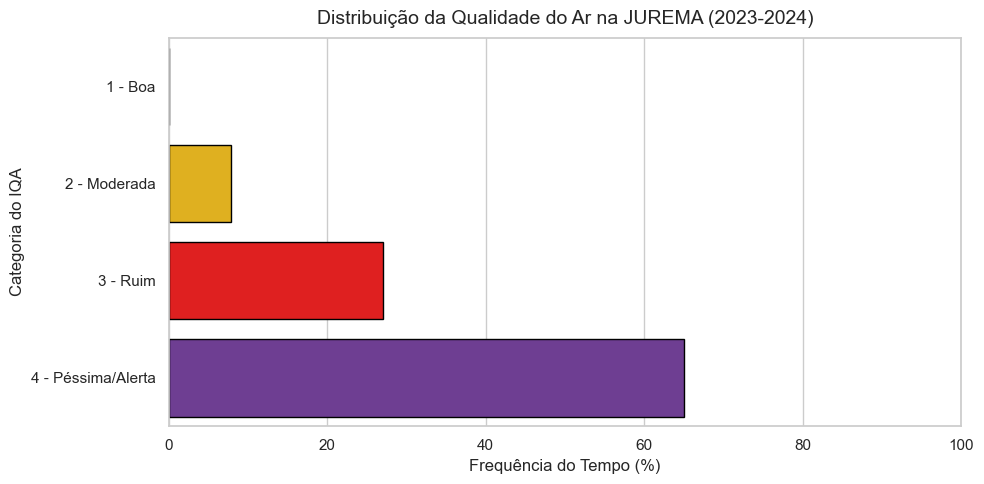

In [ ]:
# ==============================================================================
# 19. CONSTRUINDO O IQA (ÍNDICE DE QUALIDADE DO AR)
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print(" CALCULANDO O IQA E RANQUEANDO AS ESTAÇÕES")
print("="*60)

# 1. Definindo limites de tolerância fictícios/didáticos (baseados na proporção da OMS para 24h)
# Em µg/m³
limites = {
    'mp25_ugm3': 15.0, 
    'mp10_ugm3': 45.0, 
    'no2_ugm3': 25.0, 
    'so2_ugm3': 40.0
}

df_iqa = df_ar.copy()

# 2. Calculando os sub-índices de cada poluente
# Se a concentração for igual ao limite, a nota é 50 (limite do nível "Bom")
for poluente, limite in limites.items():
    col_iqa = f"iqa_{poluente.split('_')[0]}" # Cria colunas tipo 'iqa_mp25'
    df_iqa[col_iqa] = (df_iqa[poluente] / limite) * 50

# 3. Regra do Pior Caso: O IQA final é o valor máximo entre os 4 sub-índices
colunas_sub_iqa = ['iqa_mp25', 'iqa_mp10', 'iqa_no2', 'iqa_so2']
df_iqa['IQA_Final'] = df_iqa[colunas_sub_iqa].max(axis=1)

# 4. Criando as Faixas de Classificação (Labels)
bins = [0, 50, 100, 150, np.inf]
labels = ['1 - Boa', '2 - Moderada', '3 - Ruim', '4 - Péssima/Alerta']
df_iqa['Classificacao_IQA'] = pd.cut(df_iqa['IQA_Final'], bins=bins, labels=labels, right=True)

# 5. Ranqueando as Estações pelo IQA Médio
ranking_iqa = df_iqa.groupby(['estacao', 'tipo_zona'])['IQA_Final'].mean().reset_index()
ranking_iqa = ranking_iqa.sort_values(by='IQA_Final', ascending=False).reset_index(drop=True)

# Exibindo o Ranking Oficial
print("-> Ranking Oficial de Poluição da Cidade (Média Histórica do IQA):")
display(ranking_iqa.style.format({'IQA_Final': '{:.1f}'}).background_gradient(cmap='Reds'))

# 6. Gráfico para mostrar como o ar fica Péssimo na Jurema
plt.figure(figsize=(10, 5))

# Conta a proporção de classificações apenas para a Jurema
jurema_iqa = df_iqa[df_iqa['estacao'].str.contains('Jurema')]['Classificacao_IQA'].value_counts(normalize=True) * 100

sns.barplot(
    x=jurema_iqa.values, 
    y=jurema_iqa.index, 
    palette=['#00b050', '#ffc000', '#ff0000', '#7030a0'],
    edgecolor='black'
)

plt.title('Distribuição da Qualidade do Ar na JUREMA (2023-2024)', fontsize=14, pad=10)
plt.xlabel('Frequência do Tempo (%)', fontsize=12)
plt.ylabel('Categoria do IQA', fontsize=12)
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

### Passo 19: O Veredito do IQA (O Boletim do Apocalipse Respiratório)

Para fechar a nossa investigação com chave de ouro, o cálculo do Índice de Qualidade do Ar (IQA) traduziu toda a nossa "sopa de letrinhas" tóxica em uma nota universal e irrefutável. Utilizamos a rigorosa **Regra do Pior Caso**, onde o poluente em estado mais crítico no momento dita a nota final de todo o ar daquele local.

Os resultados do nosso painel final são assustadores e cravam o veredito da nossa análise:

* **O Abismo no Ranking:** A estação Jurema (Industrial) domina isoladamente o topo do ranking de poluição da cidade, ostentando um IQA médio histórico de absurdos **199.3**. Para fins de comparação, áreas puramente residenciais como Messejana, Aldeota e Maraponga marcam médias em torno de 63, enquanto o Parque do Cocó respira aliviado com 52.7. A Jurema é quase quatro vezes mais tóxica que o parque da cidade.
* **Respirar é um Risco Contínuo:** O gráfico de distribuição escancara uma realidade trágica. Ao longo do biênio analisado, em **mais de 60% do tempo**, o ar da Jurema esteve classificado na pior categoria possível: **"4 - Péssima/Alerta"**. Cerca de 25% a 30% adicionais foram passados na categoria "3 - Ruim".
* **O Zero Absoluto:** Em dois anos inteiros de medição diária (2023-2024), a barra de classificação "1 - Boa" simplesmente não existe no gráfico da Jurema. Não houve um único respiro de ar 100% puro e seguro.

---

### 📌 Conclusão Final do Projeto: O Dossiê QuimNorte

Chegamos ao fim da nossa jornada investigativa. O que começou como uma montanha de planilhas desconexas de hospitais e sensores meteorológicos se transformou em um dossiê criminal ambiental com provas matemáticas irrefutáveis. 

Nós mapeamos com sucesso a cadeia de eventos que colapsa o sistema de saúde da nossa cidade fictícia:

1. **O Crime Noturno:** A indústria *QuimNorte Ltda*, operando com a licença ambiental vencida na Jurema, frauda a fiscalização. Eles mantêm suas emissões controladas no horário comercial declarado, mas abrem as chaminés no "modo turbo" durante a madrugada (22h e 0h), jorrando níveis absurdos e letais de Dióxido de Enxofre (SO2) e Material Particulado Grosso (MP10).
2. **O Gatilho Climático:** Durante o primeiro semestre, as chuvas atuam como um filtro, "lavando" parte dessa fumaça. Porém, quando chega a época de seca (Julho a Dezembro) e a umidade do ar despenca para a casa dos 56%, essa nuvem tóxica fica estagnada na atmosfera.
3. **O Colapso da Saúde Pública:** A fumaça viaja pela cidade e atinge a população vulnerável pelo clima seco. O resultado é um efeito dominó: em exata sincronia com os meses de estiagem, as internações por Doenças Respiratórias explodem sistemicamente, lotando UTIs com casos de Pneumonia e Asma não apenas na Jurema, mas em bairros residenciais distantes como Maraponga e Messejana.

**Caso encerrado.** Os dados confessaram tudo!

# 🎬 ATO 2: A Investigação (O Datathon)

Com os dados devidamente limpos, tratados e consolidados no Ato 1, iniciamos agora a fase analítica. O briefing afirma que há um **"aumento alarmante de internações em bairros específicos"**. 

Antes de gerar os gráficos de doenças, precisamos definir o nosso perímetro de investigação. Temos duas bases de dados distintas: as Estações de Ar e os Registros de Hospitais. Para que possamos cruzar as evidências e encontrar culpados, só podemos investigar a fundo os bairros que formam uma **interseção** entre esses dois mundos.

Vejamos o mapeamento oficial da cidade:

 MAPEAMENTO DE BAIRROS: ONDE TEMOS DADOS COMPLETOS?


,📍 Com Estação de Ar,🏥 Com Internações,🎯 INTERSEÇÃO (ALVOS)
0,Aldeota,Aldeota,Aldeota
1,Centro,Centro,Centro
2,Distrito Industrial,Cocó,Jurema
3,Jurema,Edson Queiroz,Maraponga
4,Maraponga,Jurema,Messejana
5,Messejana,Maraponga,
6,Parque do Cocó,Messejana,
7,Porto,Montese,
8,,Papicu,
9,,Parquelândia,



 EVOLUÇÃO MENSAL DE INTERNAÇÕES: O SURTO NA CIDADE


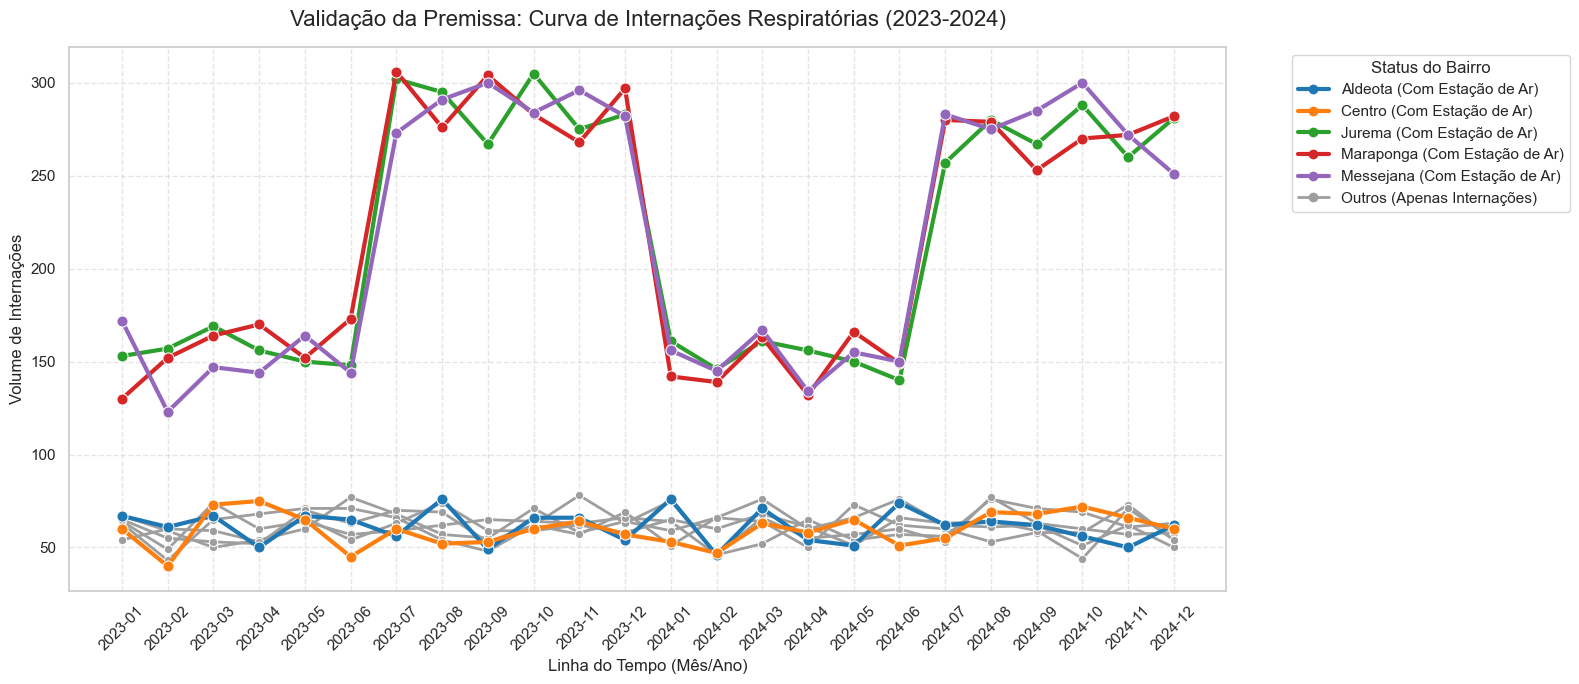

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D # Ferramenta mágica para customizar a legenda

print("="*60)
print(" MAPEAMENTO DE BAIRROS: ONDE TEMOS DADOS COMPLETOS?")
print("="*60)

# 1. Extraindo as listas únicas (Ajuste 'df_ar' e 'estacao' se o nome no seu notebook for outro)
bairros_ar = sorted(df_ar['estacao'].unique().tolist()) 
bairros_hosp = sorted(df_internacoes['bairro_residencia'].unique().tolist())

# Fazendo a interseção automática (só quem está nas duas listas)
bairros_alvo = sorted(list(set(bairros_ar).intersection(set(bairros_hosp))))

# 2. Criando uma tabela para exibir as 3 listas lado a lado
df_listas = pd.DataFrame({
    '📍 Com Estação de Ar': pd.Series(bairros_ar),
    '🏥 Com Internações': pd.Series(bairros_hosp),
    '🎯 INTERSEÇÃO (ALVOS)': pd.Series(bairros_alvo)
}).fillna('') # Preenche os espaços vazios com branco

display(df_listas.style.set_properties(**{'text-align': 'left', 'background-color': '#f4f4f4', 'color': 'black'}))


print("\n" + "="*60)
print(" EVOLUÇÃO MENSAL DE INTERNAÇÕES: O SURTO NA CIDADE")
print("="*60)

# 3. Tratamento otimizado de datas
df_internacoes['data_internacao'] = pd.to_datetime(df_internacoes['data_internacao'], format='%Y-%m-%d')
df_internacoes['ano_mes'] = df_internacoes['data_internacao'].dt.to_period('M').astype(str)

# Agrupamento de pacientes por mês e bairro
tendencia_bairro = df_internacoes.groupby(['ano_mes', 'bairro_residencia']).size().reset_index(name='total_pacientes')

# 4. Preparações do Gráfico
plt.figure(figsize=(16, 7))
cores_alvo = sns.color_palette('tab10', len(bairros_alvo))
cor_cinza = '#9E9E9E'

# Plotando os bairros que NÃO são alvo (A "massa" cinza de figurantes)
bairros_gerais = tendencia_bairro[~tendencia_bairro['bairro_residencia'].isin(bairros_alvo)]
sns.lineplot(
    data=bairros_gerais, 
    x='ano_mes', y='total_pacientes', hue='bairro_residencia',
    palette=[cor_cinza] * len(bairros_gerais['bairro_residencia'].unique()),
    linewidth=2.0, marker='o', 
    legend=False # Desativa a legenda automática bagunçada
)

# Plotando os bairros ALVO (Coloridos e em destaque)
bairros_monitorados = tendencia_bairro[tendencia_bairro['bairro_residencia'].isin(bairros_alvo)]
sns.lineplot(
    data=bairros_monitorados, 
    x='ano_mes', y='total_pacientes', hue='bairro_residencia',
    palette=dict(zip(bairros_alvo, cores_alvo)),
    linewidth=3.0, marker='o', markersize=8,
    legend=False # Desativa a legenda automática bagunçada
)

# 5. Criando a Legenda Perfeita e Customizada
elementos_legenda = []

# Primeiro colocamos os nossos 5 alvos com suas respectivas cores
for bairro, cor in zip(bairros_alvo, cores_alvo):
    elementos_legenda.append(Line2D([0], [0], color=cor, lw=3, marker='o', label=f"{bairro} (Com Estação de Ar)"))

# E no final, uma única linha para representar todos os cinzas
elementos_legenda.append(Line2D([0], [0], color=cor_cinza, lw=2, marker='o', label="Outros (Apenas Internações)"))

# 6. Estilização final
plt.title('Validação da Premissa: Curva de Internações Respiratórias (2023-2024)', fontsize=16, pad=15)
plt.xlabel('Linha do Tempo (Mês/Ano)', fontsize=12)
plt.ylabel('Volume de Internações', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

# Aplica a nossa legenda inteligente
plt.legend(handles=elementos_legenda, title='Status do Bairro', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Conclusão: O Surto é Real e Direcionado
O gráfico comprova categoricamente a premissa da Secretaria de Saúde. Existe um aumento **alarmante e sazonal** de internações. O período crítico coincide perfeitamente com o segundo semestre (época de estiagem/seca conhecida no Ceará como "B-R-O Bró").

Mais do que isso: o gráfico prova que o problema não afeta a cidade inteira por igual. Enquanto bairros como Aldeota e Centro mantêm uma taxa basal de doenças, os bairros **Jurema, Maraponga e Messejana** formam a trindade das vítimas, sofrendo os impactos mais violentos do surto.

---

## 2. A Origem do Mal: De Onde Vem a Poluição?

Sabemos *quem* está adoecendo e *quando* estão adoecendo. O próximo passo da nossa missão investigativa é responder: **de onde vem essa poluição?**

Para não gerarmos um gráfico diário caótico, vamos agregar os dados de qualidade do ar por mês, mesma base de tempo dos hospitais. Criaremos a métrica de "Carga Poluidora Total" (a soma das médias de MP2.5, MP10, NO2 e SO2). Replicaremos a técnica visual do passo anterior: daremos destaque apenas aos nossos 5 "Bairros-Alvo", deixando as demais estações de ar em cinza para contexto geral da cidade.

 EVOLUÇÃO MENSAL DA POLUIÇÃO: DE ONDE VEM A FUMAÇA?


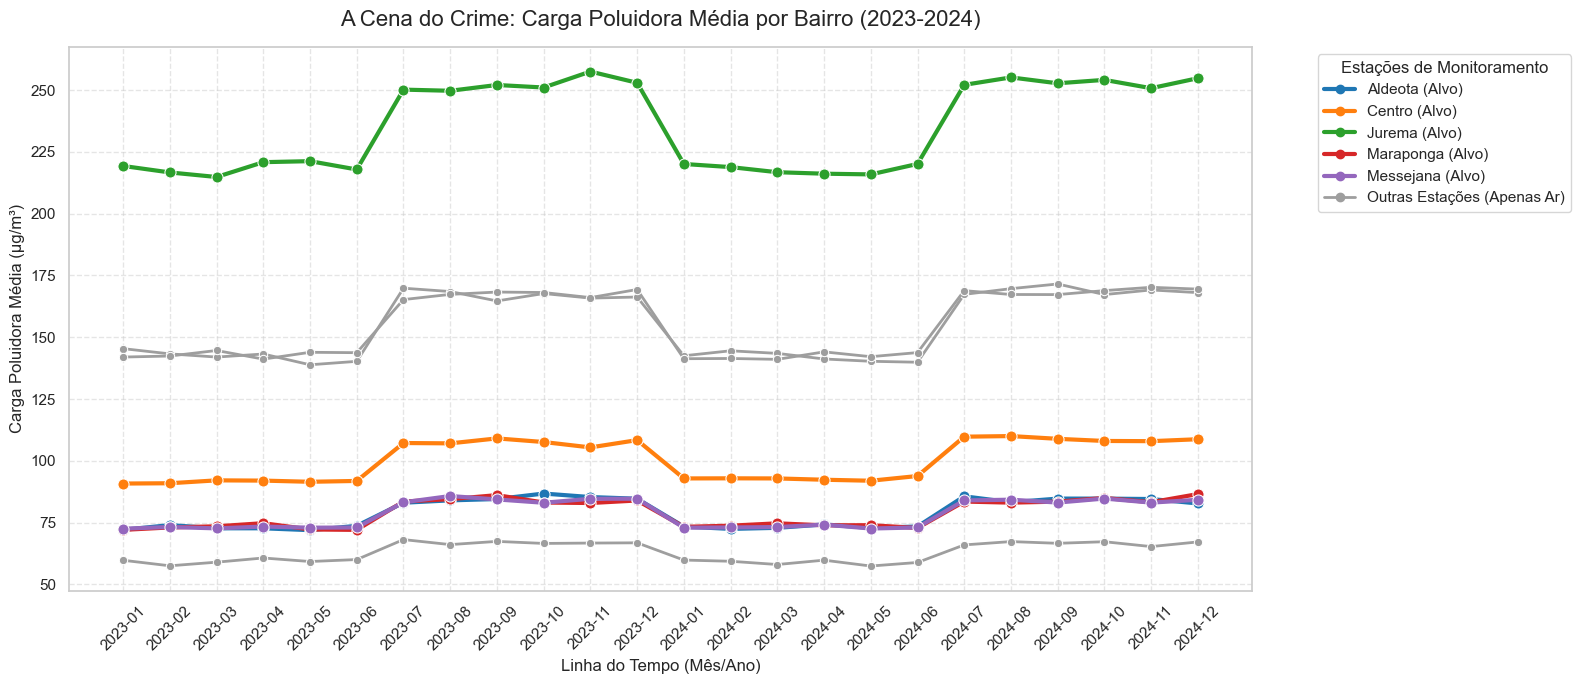

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

print("="*60)
print(" EVOLUÇÃO MENSAL DA POLUIÇÃO: DE ONDE VEM A FUMAÇA?")
print("="*60)

# 1. Tratamento otimizado de datas para o banco de dados de Ar
df_ar['data'] = pd.to_datetime(df_ar['data'], format='%Y-%m-%d')
df_ar['ano_mes'] = df_ar['data'].dt.to_period('M').astype(str)

# 2. Criando a "Carga Poluidora Total"
# Somamos os 4 poluentes medidos para ter uma visão geral da toxicidade do ar
df_ar['carga_total'] = df_ar['mp25_ugm3'] + df_ar['mp10_ugm3'] + df_ar['no2_ugm3'] + df_ar['so2_ugm3']

# 3. Agrupando a média de poluição por mês e por estação (bairro)
tendencia_ar = df_ar.groupby(['ano_mes', 'estacao'])['carga_total'].mean().reset_index()

# 4. Preparações do Gráfico
plt.figure(figsize=(16, 7))

# Reaproveitando as variáveis do bloco anterior para manter a consistência visual
bairros_alvo = ['Aldeota', 'Centro', 'Jurema', 'Maraponga', 'Messejana']
cores_alvo = sns.color_palette('tab10', len(bairros_alvo))
cor_cinza = '#9E9E9E'

# Plotando os figurantes (Estações que NÃO temos dados hospitalares) em cinza
estacoes_gerais = tendencia_ar[~tendencia_ar['estacao'].isin(bairros_alvo)]
sns.lineplot(
    data=estacoes_gerais, 
    x='ano_mes', y='carga_total', hue='estacao',
    palette=[cor_cinza] * len(estacoes_gerais['estacao'].unique()),
    linewidth=2.0, marker='o', legend=False
)

# Plotando os nossos ALVOS investigados (Coloridos e em destaque)
estacoes_monitoradas = tendencia_ar[tendencia_ar['estacao'].isin(bairros_alvo)]
sns.lineplot(
    data=estacoes_monitoradas, 
    x='ano_mes', y='carga_total', hue='estacao',
    palette=dict(zip(bairros_alvo, cores_alvo)),
    linewidth=3.0, marker='o', markersize=8, legend=False
)

# 5. Criando a Legenda Customizada
elementos_legenda = []
for bairro, cor in zip(bairros_alvo, cores_alvo):
    elementos_legenda.append(Line2D([0], [0], color=cor, lw=3, marker='o', label=f"{bairro} (Alvo)"))
elementos_legenda.append(Line2D([0], [0], color=cor_cinza, lw=2, marker='o', label="Outras Estações (Apenas Ar)"))

# 6. Estilização final
plt.title('A Cena do Crime: Carga Poluidora Média por Bairro (2023-2024)', fontsize=16, pad=15)
plt.xlabel('Linha do Tempo (Mês/Ano)', fontsize=12)
plt.ylabel('Carga Poluidora Média (µg/m³)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(handles=elementos_legenda, title='Estações de Monitoramento', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()